In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import ttest_ind
from statsmodels.stats.weightstats import ztest
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
#GitHub URL, not the blob (webpage) URL
url = 'https://raw.githubusercontent.com/ROYSOMNATH98350/German-Credit-Risk-Data-Cleaned/main/german_credit_risk_data_cleaned.csv'

df = pd.read_csv(url)
df.head()

,Customer.Id,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,M6769,67,Male,2,Own,Little,Little,1169,6,Radio/Tv
1,F2251,22,Female,2,Own,Little,Moderate,5951,48,Radio/Tv
2,M4996,49,Male,1,Own,Little,Moderate,2096,12,Education
3,M4582,45,Male,2,Free,Little,Little,7882,42,Furniture/Equipment
4,M5370,53,Male,2,Free,Little,Little,4870,24,Car


<Axes: xlabel='Age', ylabel='Credit amount'>

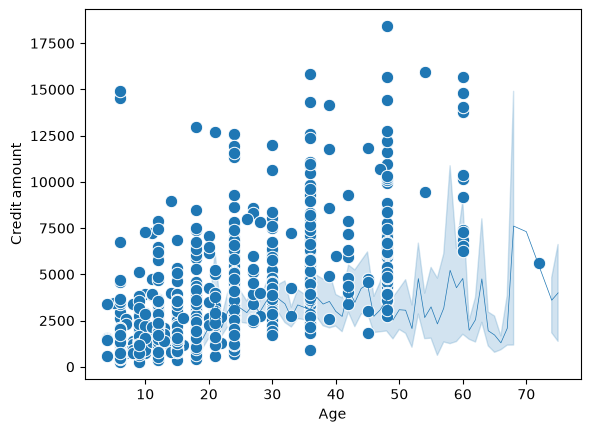

In [4]:
# Scatterplot Chart
sns.lineplot(x='Age', y='Credit amount', data=df, linewidth=0.5)   # thicker
sns.scatterplot(x='Duration', y='Credit amount', data=df, s=80)  # bigger dots

In [14]:
#Interactive Scatter
fig = px.scatter(
    df,
    x="Duration",
    y="Credit amount",
    color="Sex",
    hover_data=[
        "Age", "Purpose", "Job",  "Customer.Id","Housing",
        "Duration", "Credit amount"
    ],
    title="Duration vs Credit Amount"
)

fig.show()

In [ ]:
# Dataset Info
df.info()
print("\nMissing values per column:")
print(df.isna().sum())


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Customer.Id       1000 non-null   str  
 1   Age               1000 non-null   int64
 2   Sex               1000 non-null   str  
 3   Job               1000 non-null   int64
 4   Housing           1000 non-null   str  
 5   Saving accounts   1000 non-null   str  
 6   Checking account  1000 non-null   str  
 7   Credit amount     1000 non-null   int64
 8   Duration          1000 non-null   int64
 9   Purpose           1000 non-null   str  
dtypes: int64(4), str(6)
memory usage: 78.3 KB

Missing values per column:
Customer.Id         0
Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
dtype: int64


In [19]:
# 1. CHECKING THE VARIANCE WITH DETAILED STATISTICS
print("=== Credit Amount Statistics ===")
print(f"Mean: {df['Credit amount'].mean():.2f}")
print(f"Median: {df['Credit amount'].median():.2f}")
print(f"Standard Deviation: {df['Credit amount'].std():.2f}")
print(f"Variance: {df['Credit amount'].var():.2f}")
print(f"Min: {df['Credit amount'].min():.2f}")
print(f"Max: {df['Credit amount'].max():.2f}")
print(f"Range: {df['Credit amount'].max() - df['Credit amount'].min():.2f}")


=== Credit Amount Statistics ===
Mean: 3271.26
Median: 2319.50
Standard Deviation: 2822.74
Variance: 7967843.47
Min: 250.00
Max: 18424.00
Range: 18174.00


In [20]:
# CHECKING THE DISTRIBUTION
print("\n=== Distribution Analysis ===")
print(df['Credit amount'].describe())



=== Distribution Analysis ===
count     1000.000000
mean      3271.258000
std       2822.736876
min        250.000000
25%       1365.500000
50%       2319.500000
75%       3972.250000
max      18424.000000
Name: Credit amount, dtype: float64


In [22]:
# CHECKING OUTLIERS IMPACT
q1 = df['Credit amount'].quantile(0.25)
q3 = df['Credit amount'].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
lower_bound = q1 - 1.5 * iqr
outliers = df[(df['Credit amount'] > upper_bound) | (df['Credit amount'] < lower_bound)]
print(f"\nNumber of outliers: {len(outliers)}")
print(f"Percentage of outliers: {len(outliers)/len(df)*100:.1f}%")
print(f"Outlier range: {lower_bound:.2f} to {upper_bound:.2f}")



Number of outliers: 72
Percentage of outliers: 7.2%
Outlier range: -2544.62 to 7882.38


In [23]:
# CHECKING SKEWNESS
print(f"\n=== Skewness ===")
skewness = df['Credit amount'].skew()
print(f"Skewness: {skewness:.2f}")
if skewness > 1:
    print("Highly right-skewed (positive skew) - explains high variance")
elif skewness > 0.5:
    print("Moderately right-skewed")
else:
    print("Approximately symmetric")



=== Skewness ===
Skewness: 1.95
Highly right-skewed (positive skew) - explains high variance


In [24]:
# CHECKING STANDARD DEVIATION IN CONTEXT
print("\n=== Standard Deviation Context ===")
print(f"Mean: ${df['Credit amount'].mean():.2f}")
print(f"Std Dev: ${df['Credit amount'].std():.2f}")
print(f"Mean ± 1 Std Dev: ${df['Credit amount'].mean() - df['Credit amount'].std():.2f} to ${df['Credit amount'].mean() + df['Credit amount'].std():.2f}")
print(f"Mean ± 2 Std Dev: ${df['Credit amount'].mean() - 2*df['Credit amount'].std():.2f} to ${df['Credit amount'].mean() + 2*df['Credit amount'].std():.2f}")



=== Standard Deviation Context ===
Mean: $3271.26
Std Dev: $2822.74
Mean ± 1 Std Dev: $448.52 to $6093.99
Mean ± 2 Std Dev: $-2374.22 to $8916.73


In [ ]:
# Calculate statistics
mean_val = df['Credit amount'].mean()
median_val = df['Credit amount'].median()
std_val = df['Credit amount'].std()
skewness = df['Credit amount'].skew()
q1 = df['Credit amount'].quantile(0.25)
q3 = df['Credit amount'].quantile(0.75)

# Removing outliers for better visualization (99th percentile)
p99 = df['Credit amount'].quantile(0.99)
df_filtered = df[df['Credit amount'] <= p99]  # Filter out top 1% outliers

# HISTOGRAM WITH CLEAN LAYOUT
fig1 = px.histogram(df, x='Credit amount', 
                    title='Credit Amount Distribution',
                    labels={'Credit amount': 'Credit Amount ($)'},
                    nbins=50,
                    opacity=0.7,
                    hover_data=['Customer.Id', 'Age', 'Purpose'])

# Adding statistics as separate annotations at different positions to avoid overlap
fig1.add_vline(x=mean_val, line_dash="dash", line_color="red", 
               annotation_text="Mean", annotation_position="top right")
fig1.add_vline(x=median_val, line_dash="dash", line_color="green",
               annotation_text="Median", annotation_position="top left")
fig1.add_vline(x=q1, line_dash="dot", line_color="orange",
               annotation_text="Q1", annotation_position="bottom right")
fig1.add_vline(x=q3, line_dash="dot", line_color="orange",
               annotation_text="Q3", annotation_position="bottom left")

# Adding statistics as a clean annotation box (positioned outside the plot area)
stats_text = f"""
<b>Statistics Summary</b><br>
Mean: ${mean_val:,.0f}<br>
Median: ${median_val:,.0f}<br>
Std Dev: ${std_val:,.0f}<br>
Skewness: {skewness:.2f}<br>
Q1 (25%): ${q1:,.0f}<br>
Q3 (75%): ${q3:,.0f}<br>
IQR: ${q3-q1:,.0f}
"""

fig1.add_annotation(
    text=stats_text,
    xref="paper", yref="paper",
    x=0.78, y=0.98,  # Position in top-right corner
    showarrow=False,
    font=dict(size=11, color="black"),
    bgcolor="rgba(255, 255, 255, 0.9)",
    bordercolor="black",
    borderwidth=1,
    align="left",
    xanchor="left",
    yanchor="top"
)

fig1.update_layout(
    template='plotly_white',
    width=1000,
    height=600,
    hovermode='closest',
    xaxis_title='Credit Amount ($)',
    yaxis_title='Count',
    showlegend=False
)

fig1.show()

In [26]:
# INTERACTIVE SCATTER WITH OUTLIER HIGHLIGHTING
# Identify outliers (beyond Q3 + 1.5*IQR)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
df['Is_Outlier'] = df['Credit amount'] > upper_bound

fig5 = px.scatter(df, x='Duration', y='Credit amount',
                  title='Credit Amount vs Duration (Outliers Highlighted)',
                  labels={'Credit amount': 'Credit Amount ($)', 'Duration': 'Duration (months)'},
                  hover_data=['Customer.Id', 'Age', 'Purpose', 'Saving accounts'],
                  color='Is_Outlier',
                  color_discrete_map={True: 'red', False: 'blue'},
                  size='Age',
                  opacity=0.6)

# Adding horizontal lines for quartiles
fig5.add_hline(y=q1, line_dash="dot", line_color="orange", annotation_text=f"Q1: ${q1:,.0f}")
fig5.add_hline(y=median_val, line_dash="dash", line_color="green", annotation_text=f"Median: ${median_val:,.0f}")
fig5.add_hline(y=q3, line_dash="dot", line_color="orange", annotation_text=f"Q3: ${q3:,.0f}")
fig5.add_hline(y=upper_bound, line_dash="dash", line_color="red", annotation_text=f"Outlier Threshold: ${upper_bound:,.0f}")

# Adding statistics annotation
outlier_count = df['Is_Outlier'].sum()
outlier_pct = (outlier_count / len(df)) * 100

stats_text3 = f"""
<b>Outlier Analysis:</b><br>
Outliers detected: {outlier_count} ({outlier_pct:.1f}% of data)<br>
Upper bound (Q3 + 1.5*IQR): ${upper_bound:,.0f}<br>
Maximum value: ${df['Credit amount'].max():,.0f}<br>
Skewness: {skewness:.2f}
"""

fig5.add_annotation(
    text=stats_text3,
    xref="paper", yref="paper",
    x=0.78, y=0.98,
    showarrow=False,
    font=dict(size=11),
    bgcolor="rgba(255, 255, 255, 0.9)",
    bordercolor="black",
    borderwidth=1,
    align="left",
    xanchor="left",
    yanchor="top"
)

fig5.update_layout(
    template='plotly_white',
    width=1000,
    height=600
)

fig5.show()

In [8]:
# 2. AGE_STATUS SEGMENT
conditions = [
    df['Age'] > 65,
    (df['Age'] >= 50) & (df['Age'] <= 64),
    (df['Age'] >= 31) & (df['Age'] <= 49),
    (df['Age'] >= 18) & (df['Age'] <= 30)
]
choices = ['Very Old Age', 'Early Old Age', 'Middle Age', 'Young Age']
df['Age_Status'] = np.select(conditions, choices, default='Unknown')

In [10]:
# 3. TENURE_STATUS SEGMENT (Based on Duration)
conditions = [
    df['Duration'] < 12,
    (df['Duration'] >= 12) & (df['Duration'] <= 24),
    (df['Duration'] >= 25) & (df['Duration'] <= 42),
    df['Duration'] > 42
]
choices = ['Small Tenure', 'Medium Tenure', 'Long Tenure', 'Extremely Long Tenure']
df['Tenure_Status'] = np.select(conditions, choices, default='Unknown')


In [11]:
# 4. CREDIT_TIER SEGMENT (Based on Credit Amount)
conditions = [
    df['Credit amount'] < 1500,
    (df['Credit amount'] >= 1500) & (df['Credit amount'] < 3000),
    (df['Credit amount'] >= 3000) & (df['Credit amount'] < 6000),
    (df['Credit amount'] >= 6000) & (df['Credit amount'] < 8000),
    (df['Credit amount'] >= 8000) & (df['Credit amount'] < 10000),
    df['Credit amount'] >= 10000
]
choices = ['Modest', 'Lower Mediate', 'Intermediate', 'Upper Mediate', 'Very High', 'Extremely High']
df['Credit_Tier'] = np.select(conditions, choices, default='Unknown')


In [12]:
# 5. EMPLOYMENT_STATUS SEGMENT (Based on Job)
job_mapping = {
    0: 'Unskilled Non-Resident',
    1: 'Unskilled',
    2: 'Skilled',
    3: 'Highly Skilled'
}
df['Employment_Status'] = df['Job'].map(job_mapping)


In [13]:
# 6. LOAN_PURPOSE (Cleaned Purpose Column)
purpose_mapping = {
    'Car': 'Vehicle',
    'Radio/Tv': 'Electronic Appliances',
    'Furniture/Equipment': 'Household Furnishings',
    'Vacation/Others': 'Vacations',
    'Repairs': 'Maintenance'
}
df['Loan_Purpose'] = df['Purpose'].replace(purpose_mapping)

In [14]:
# 7. ACCOUNT_STATUS SEGMENT (Savings vs Checking Match)
# Step 1: Replace 'Quite Rich' with 'Rich' in Savings account
df['Saving accounts'] = df['Saving accounts'].replace('Quite Rich', 'Rich')

# Step 2: Create Account_Status
df['Account_Status'] = (df['Saving accounts'] == df['Checking account']).map({True: 'Matched', False: 'Unmatched'})

In [15]:
# TENURE_STATUS SEGMENT (Based on Duration)
# ============================================================
conditions = [
    df['Duration'] < 12,
    (df['Duration'] >= 12) & (df['Duration'] <= 24),
    (df['Duration'] >= 25) & (df['Duration'] <= 42),
    df['Duration'] > 42
]
choices = ['Small Tenure', 'Medium Tenure', 'Long Tenure', 'Extremely Long Tenure']
df['Tenure_Status'] = np.select(conditions, choices, default='Unknown')

In [16]:
# Combine 'Quite Rich' into 'Rich' in Savings account
df['Saving accounts'] = df['Saving accounts'].replace('Quite Rich', 'Rich')

# Verify the changes
print("=== Updated Savings Account Distribution ===")
print(df['Saving accounts'].value_counts())
print("\n=== Updated Savings Account Distribution with Percentages ===")
print(df['Saving accounts'].value_counts(normalize=True) * 100)


=== Updated Savings Account Distribution ===
Saving accounts
Little      741
Rich        132
Moderate    127
Name: count, dtype: int64

=== Updated Savings Account Distribution with Percentages ===
Saving accounts
Little      74.1
Rich        13.2
Moderate    12.7
Name: proportion, dtype: float64


In [17]:
# 8. VERIFY ALL SEGMENTS
print("=== All Segments Created Successfully ===")
print("\n1. Age_Status:")
print(df['Age_Status'].value_counts())
print("\n2. Tenure_Status:")
print(df['Tenure_Status'].value_counts())
print("\n3. Credit_Tier:")
print(df['Credit_Tier'].value_counts())
print("\n4. Employment_Status:")
print(df['Employment_Status'].value_counts())
print("\n5. Loan_Purpose:")
print(df['Loan_Purpose'].value_counts())
print("\n6. Account_Status:")
print(df['Account_Status'].value_counts())


=== All Segments Created Successfully ===

1. Age_Status:
Age_Status
Middle Age       464
Young Age        411
Early Old Age    102
Very Old Age      18
Unknown            5
Name: count, dtype: int64

2. Tenure_Status:
Tenure_Status
Medium Tenure            590
Small Tenure             180
Long Tenure              160
Extremely Long Tenure     70
Name: count, dtype: int64

3. Credit_Tier:
Credit_Tier
Lower Mediate     314
Modest            306
Intermediate      231
Upper Mediate      79
Extremely High     40
Very High          30
Name: count, dtype: int64

4. Employment_Status:
Employment_Status
Skilled                   630
Unskilled                 200
Highly Skilled            148
Unskilled Non-Resident     22
Name: count, dtype: int64

5. Loan_Purpose:
Loan_Purpose
Vehicle                  337
Electronic Appliances    280
Household Furnishings    181
Business                  97
Education                 59
Maintenance               22
Domestic Appliances       12
Vacations        

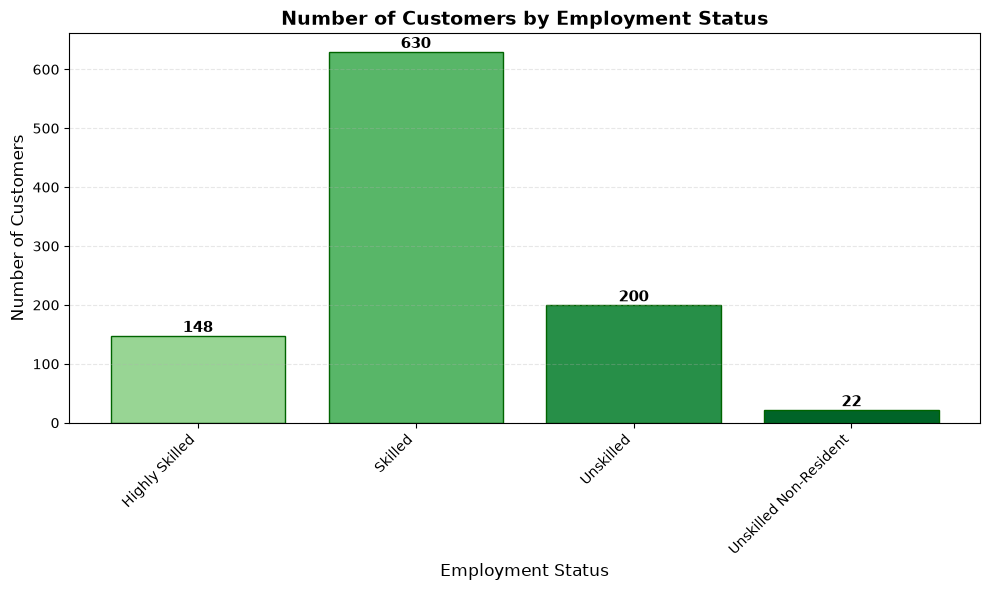

In [18]:
# Get count of customers by Employment Status
emp_counts = df['Employment_Status'].value_counts().reset_index()
emp_counts.columns = ['Employment_Status', 'Count']
emp_counts = emp_counts.sort_values('Employment_Status')

# Create the chart
plt.figure(figsize=(10, 6))
colors = plt.cm.Greens(np.linspace(0.4, 0.9, len(emp_counts)))
bars = plt.bar(emp_counts['Employment_Status'], emp_counts['Count'], color=colors, edgecolor='darkgreen', linewidth=1)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# Customize the chart
plt.title('Number of Customers by Employment Status', fontsize=14, fontweight='bold')
plt.xlabel('Employment Status', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()

# Show the chart
plt.show()

In [ ]:
# # Get count of customers by Age Status
import plotly.graph_objects as go
import pandas as pd

# Get count of customers by Age_Status
age_counts = df['Age_Status'].value_counts().reset_index()
age_counts.columns = ['Age_Status', 'Count']
# Sort in proper order
age_order = ['Young Age', 'Middle Age', 'Early Old Age', 'Very Old Age']
age_counts['Age_Status'] = pd.Categorical(age_counts['Age_Status'], categories=age_order, ordered=True)
age_counts = age_counts.sort_values('Age_Status')

# Create the chart
fig = go.Figure(data=[
    go.Bar(
        x=age_counts['Age_Status'],
        y=age_counts['Count'],
        marker_color='purple',
        text=age_counts['Count'],
        textposition='outside',
        textfont=dict(size=12, color='black')
    )
])

fig.update_layout(
    title='Number of Customers by Age Status',
    xaxis_title='Age Status',
    yaxis_title='Number of Customers',
    template='plotly_white',
    height=500,
    width=900,
    showlegend=False
)

fig.show()

C:\Users\my pc\AppData\Local\Temp\ipykernel_13040\969521046.py:9: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  age_counts['Age_Status'] = pd.Categorical(age_counts['Age_Status'], categories=age_order, ordered=True)


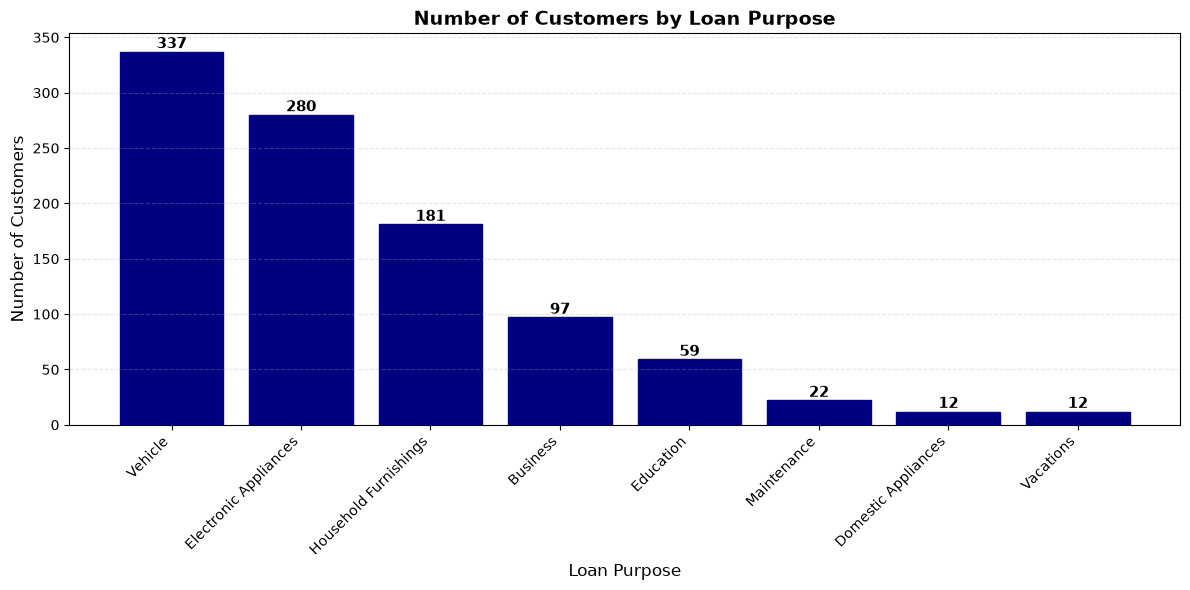

In [34]:
# Get count of customers by Loan_Purpose
loan_counts = df['Loan_Purpose'].value_counts().reset_index()
loan_counts.columns = ['Loan_Purpose', 'Count']
# Sort by count descending for better visualization
loan_counts = loan_counts.sort_values('Count', ascending=False)

# Create the chart
plt.figure(figsize=(12, 6))
bars = plt.bar(loan_counts['Loan_Purpose'], loan_counts['Count'], color='navy', edgecolor='darkblue', linewidth=1)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# Customize the chart
plt.title('Number of Customers by Loan Purpose', fontsize=14, fontweight='bold')
plt.xlabel('Loan Purpose', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()

# Show the chart
plt.show()

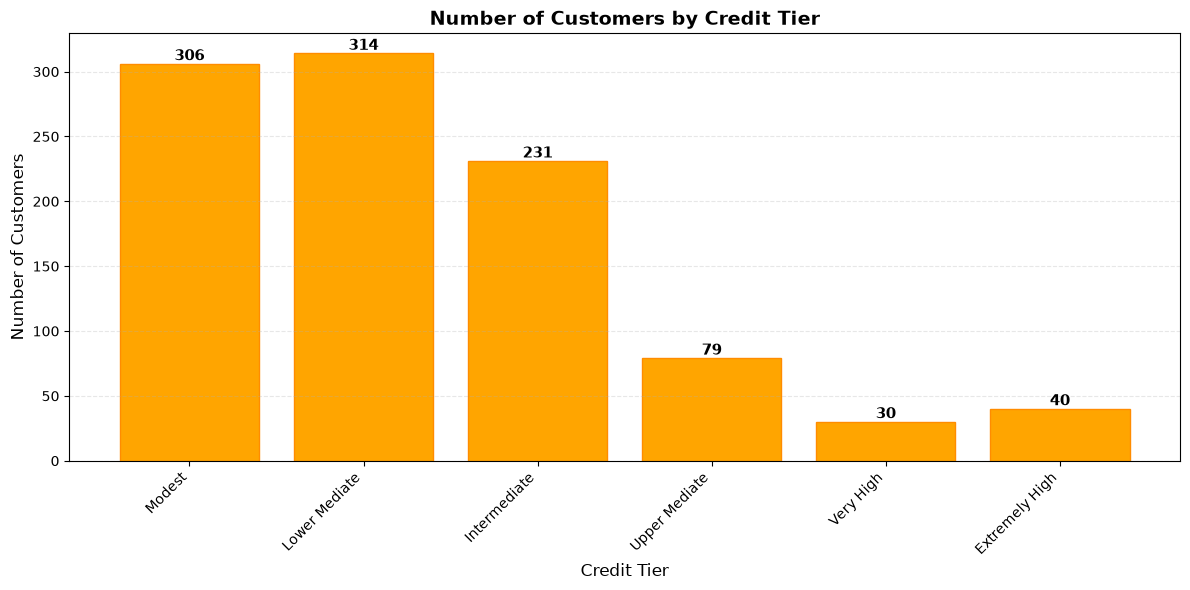

In [35]:
# Get count of customers by Credit_Tier
credit_counts = df['Credit_Tier'].value_counts().reset_index()
credit_counts.columns = ['Credit_Tier', 'Count']
# Sort in proper order (Modest, Lower Mediate, Intermediate, Upper Mediate, Very High, Extremely High)
credit_order = ['Modest', 'Lower Mediate', 'Intermediate', 'Upper Mediate', 'Very High', 'Extremely High']
credit_counts['Credit_Tier'] = pd.Categorical(credit_counts['Credit_Tier'], categories=credit_order, ordered=True)
credit_counts = credit_counts.sort_values('Credit_Tier')

# Create the chart
plt.figure(figsize=(12, 6))
bars = plt.bar(credit_counts['Credit_Tier'], credit_counts['Count'], color='orange', edgecolor='darkorange', linewidth=1)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# Customize the chart
plt.title('Number of Customers by Credit Tier', fontsize=14, fontweight='bold')
plt.xlabel('Credit Tier', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()

# Show the chart
plt.show()

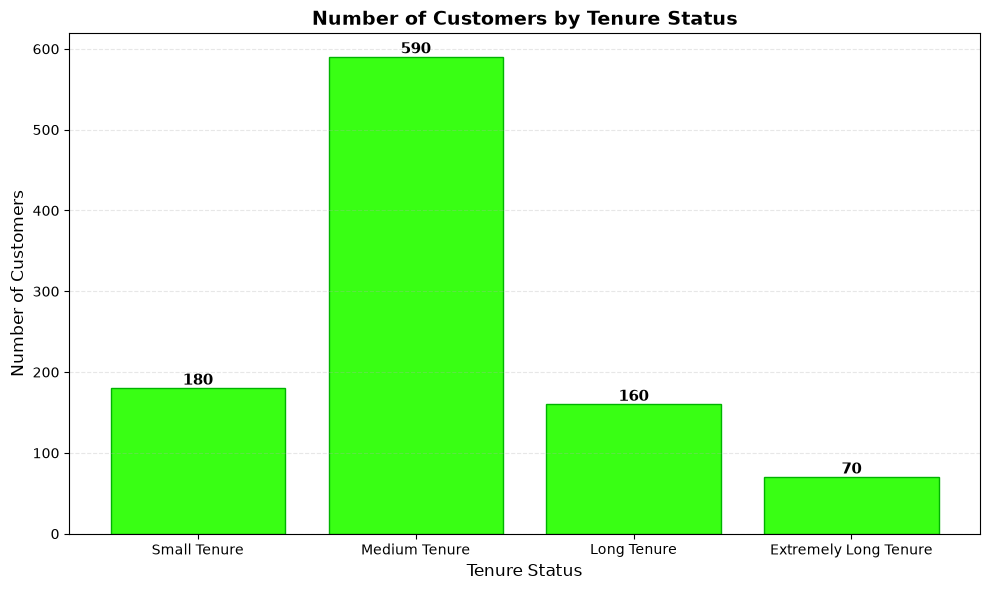

In [39]:
# Get count of customers by Tenure_Status
tenure_counts = df['Tenure_Status'].value_counts().reset_index()
tenure_counts.columns = ['Tenure_Status', 'Count']
# Sort in proper order (Small Tenure, Medium Tenure, Long Tenure, Extremely Long Tenure)
tenure_order = ['Small Tenure', 'Medium Tenure', 'Long Tenure', 'Extremely Long Tenure']
tenure_counts['Tenure_Status'] = pd.Categorical(tenure_counts['Tenure_Status'], categories=tenure_order, ordered=True)
tenure_counts = tenure_counts.sort_values('Tenure_Status')

# Create the chart
plt.figure(figsize=(10, 6))
bars = plt.bar(tenure_counts['Tenure_Status'], tenure_counts['Count'], color='#39FF14', edgecolor='#00B300', linewidth=1)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# Customize the chart
plt.title('Number of Customers by Tenure Status', fontsize=14, fontweight='bold')
plt.xlabel('Tenure Status', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()

# Show the chart
plt.show()

In [ ]:
#----------------------------------------------------Initial Insights------------------------------------------------------------
# By Employment_Status; ‘Skilled’ customers are the highest in count which is 630 out of 1000. Whereas 'Unskilled' and 'Highly_Skilled' stands for 200 and 148 counts.
# By Age_Status; ‘Young’ and ‘Middle’ age are dominating, ‘Young Age’: 411 and ‘Middle Age’: 464 out of total counts.
# By Loan_Purpose; Top 3 categories are ‘Vehicle’: 337, ‘Electronics Appliances’: 280, and ‘Household Furnishings ‘: 181.
# By credit_Tier; ‘Modest’: 306, and ‘Lower Mediate’: 314 are Top 2 by category and ‘Intermediate’: 231 stands in third position by count.
# By Tenure_Status; 'Medium Tenure' is dominating the category with the count of 590. Whereas 'Small' and 'Long' Tenure stands for 180 and 160 counts.

In [19]:
# Count of Credit amount Distribution by Employement Status

import plotly.express as px

# Create the box plot
fig = px.box(df, 
             x='Employment_Status', 
             y='Credit amount',
             title='Credit Amount Distribution by Employment Status',
             labels={'Employment_Status': 'Employment Status', 'Credit amount': 'Credit Amount ($)'},
             color='Employment_Status',
             color_discrete_sequence=px.colors.qualitative.Set2,
             points='all',  # Shows all data points
             height=600,
             width=1000)

# Set y-axis range from 0 to 20,000
fig.update_layout(
    template='plotly_white',
    xaxis_title='Employment Status',
    yaxis_title='Credit Amount ($)',
    yaxis=dict(range=[0, 20000]),
    showlegend=False
)

fig.show()

In [ ]:
# Count of Credit amount Distribution by Age Status
import plotly.express as px

# Remove 'Unknown' category if it exists
df_clean = df[df['Age_Status'] != 'Unknown']

# Get order by count (descending)
age_order = df_clean['Age_Status'].value_counts().index.tolist()

# Define bright color mapping
color_map = {
    'Young Age': '#FF0000',      # Red
    'Middle Age': '#00AA00',     # Green
    'Early Old Age': '#FF8C00',  # Dark Orange
    'Very Old Age': '#8B008B'    # Dark Purple
}

# Create the box plot
fig = px.box(df_clean, 
             x='Age_Status', 
             y='Credit amount',
             title='Credit Amount Distribution by Age Status',
             labels={'Age_Status': 'Age Status', 'Credit amount': 'Credit Amount ($)'},
             color='Age_Status',
             color_discrete_map=color_map,
             points='all',
             category_orders={'Age_Status': age_order},  # Sort by count descending
             height=600,
             width=1000)

# Set y-axis range from 0 to 20,000
fig.update_layout(
    template='plotly_white',
    xaxis_title='Age Status',
    yaxis_title='Credit Amount ($)',
    yaxis=dict(range=[0, 20000]),
    showlegend=True,
    legend=dict(title='Age Status')
)

fig.show()

In [ ]:
# Count of Credit amount Distribution by Loan Purpose
import plotly.express as px

# Get order by count (descending)
purpose_order = df['Loan_Purpose'].value_counts().index.tolist()

# Define bright color mapping
color_map = {
    'Vehicle': '#FF0000',
    'Electronic Appliances': '#0066CC',
    'Household Furnishings': '#00AA00',
    'Business': '#FF8C00',
    'Education': '#8B008B',
    'Maintenance': '#FF1493',
    'Domestic Appliances': '#00CED1',
    'Vacations': '#FFD700'
}

# Create the box plot
fig = px.box(df, 
             x='Loan_Purpose', 
             y='Credit amount',
             title='Credit Amount Distribution by Loan Purpose',
             labels={'Loan_Purpose': 'Loan Purpose', 'Credit amount': 'Credit Amount ($)'},
             color='Loan_Purpose',
             color_discrete_map=color_map,
             points='all',
             category_orders={'Loan_Purpose': purpose_order},  # Sort by count descending
             height=600,
             width=1100)

# Set y-axis range from 0 to 20,000
fig.update_layout(
    template='plotly_white',
    xaxis_title='Loan Purpose',
    yaxis_title='Credit Amount ($)',
    yaxis=dict(range=[0, 20000]),
    showlegend=True,
    legend=dict(title='Loan Purpose')
)

fig.show()

In [ ]:
# Count of Credit amount Distribution by Tenure Status
import plotly.express as px

# Remove 'Unknown' category if it exists
df_clean = df[df['Tenure_Status'] != 'Unknown']

# Get order by count (descending)
tenure_order = df_clean['Tenure_Status'].value_counts().index.tolist()

# Define bright color mapping
color_map = {
    'Small Tenure': '#FF0000',        # Red
    'Medium Tenure': '#0066CC',       # Blue
    'Long Tenure': '#FF8C00',         # Dark Orange
    'Extremely Long Tenure': '#8B008B' # Dark Purple
}

# Create the box plot
fig = px.box(df_clean, 
             x='Tenure_Status', 
             y='Credit amount',
             title='Credit Amount Distribution by Tenure Status',
             labels={'Tenure_Status': 'Tenure Status', 'Credit amount': 'Credit Amount ($)'},
             color='Tenure_Status',
             color_discrete_map=color_map,
             points='all',
             category_orders={'Tenure_Status': tenure_order},  # Sort by count descending
             height=600,
             width=1000)

# Set y-axis range from 0 to 20,000
fig.update_layout(
    template='plotly_white',
    xaxis_title='Tenure Status',
    yaxis_title='Credit Amount ($)',
    yaxis=dict(range=[0, 20000]),
    showlegend=True,
    legend=dict(title='Tenure Status')
)

fig.show()

In [52]:
# Create Monthly_EMI column
df['Monthly_EMI'] = df['Credit amount'] / df['Duration']

In [ ]:
# Monthly EMI Stats by Age Series (Aggregated)
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

# Calculate average EMI by Age
age_emi = df.groupby('Age')['Monthly_EMI'].mean().reset_index()
age_emi.columns = ['Age', 'Avg_EMI']
age_emi = age_emi.sort_values('Age')

# Create subplots
fig = make_subplots(rows=1, cols=2, 
                    subplot_titles=('Average EMI by Age (Straight Line)', 
                                  'Average EMI by Age (Logistic Trend)'))

# Chart 1: Straight line with markers
fig.add_trace(go.Scatter(
    x=age_emi['Age'],
    y=age_emi['Avg_EMI'],
    mode='lines+markers',
    name='Average EMI',
    line=dict(color='steelblue', width=2),
    marker=dict(size=8, color='steelblue', symbol='circle'),
    hovertemplate='<b>Age: %{x} years</b><br>Avg EMI: $%{y:.2f}<extra></extra>'
), row=1, col=1)

# Chart 2: Logistic trend
# Fit polynomial trend (since logistic can be tricky)
z = np.polyfit(age_emi['Age'].values, age_emi['Avg_EMI'].values, 3)
p = np.poly1d(z)
x_smooth = np.linspace(age_emi['Age'].min(), age_emi['Age'].max(), 200)
y_smooth = p(x_smooth)

fig.add_trace(go.Scatter(
    x=age_emi['Age'],
    y=age_emi['Avg_EMI'],
    mode='markers',
    name='Actual Data',
    marker=dict(size=8, color='steelblue', symbol='circle'),
    hovertemplate='<b>Age: %{x} years</b><br>Avg EMI: $%{y:.2f}<extra></extra>'
), row=1, col=2)

fig.add_trace(go.Scatter(
    x=x_smooth,
    y=y_smooth,
    mode='lines',
    name='Trend Line',
    line=dict(color='red', width=3, dash='dash'),
    hovertemplate='<b>Age: %{x:.0f} years</b><br>Trend EMI: $%{y:.2f}<extra></extra>'
), row=1, col=2)

# Update layout
fig.update_layout(
    title='Monthly EMI Trends by Age',
    template='plotly_white',
    width=1200,
    height=500,
    showlegend=True,
    grid=dict(rows=1, columns=2)
)

# Add gridlines and axis labels
fig.update_xaxes(title_text='Age (years)', row=1, col=1, showgrid=True, gridwidth=0.5, gridcolor='lightgray')
fig.update_yaxes(title_text='Average Monthly EMI ($)', row=1, col=1, showgrid=True, gridwidth=0.5, gridcolor='lightgray')
fig.update_xaxes(title_text='Age (years)', row=1, col=2, showgrid=True, gridwidth=0.5, gridcolor='lightgray')
fig.update_yaxes(title_text='Average Monthly EMI ($)', row=1, col=2, showgrid=True, gridwidth=0.5, gridcolor='lightgray')

fig.show()

In [ ]:
# Monthly EMI Stats by Age Series (Non-Aggregated)
import plotly.graph_objects as go
import numpy as np

# Sort data by Age
df_sorted = df.sort_values('Age')

# Create the chart
fig = go.Figure()

# Add individual EMI line with markers
fig.add_trace(go.Scatter(
    x=df_sorted['Age'],
    y=df_sorted['Monthly_EMI'],
    mode='lines+markers',
    name='Monthly EMI',
    line=dict(color='steelblue', width=1),
    marker=dict(size=4, color='steelblue', opacity=0.7),
    hovertemplate='<b>Age: %{x} years</b><br>EMI: $%{y:.2f}<br>Customer: %{customdata}<extra></extra>',
    customdata=df_sorted['Customer.Id']
))

# Add trend line
z = np.polyfit(df_sorted['Age'], df_sorted['Monthly_EMI'], 3)
p = np.poly1d(z)
x_trend = np.linspace(df_sorted['Age'].min(), df_sorted['Age'].max(), 200)
y_trend = p(x_trend)

fig.add_trace(go.Scatter(
    x=x_trend,
    y=y_trend,
    mode='lines',
    name='Trend Line',
    line=dict(color='red', width=2, dash='dash')
))

# Update layout
fig.update_layout(
    title='Monthly EMI vs Age (Individual Customers)',
    xaxis_title='Age (years)',
    yaxis_title='Monthly EMI ($)',
    template='plotly_white',
    width=1000,
    height=600,
    hovermode='closest'
)

# Add gridlines
fig.update_xaxes(showgrid=True, gridwidth=0.5, gridcolor='lightgray')
fig.update_yaxes(showgrid=True, gridwidth=0.5, gridcolor='lightgray')

fig.show()

In [ ]:
# Monthly EMI Distribution by Age Status
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. BOX PLOT: EMI vs Age_Status
# Remove 'Unknown' category if it exists
df_clean = df[df['Age_Status'] != 'Unknown']

# Get order by count (descending)
age_order = df_clean['Age_Status'].value_counts().index.tolist()

# Define bright color mapping
age_color_map = {
    'Young Age': '#FF0000',      # Red
    'Middle Age': '#00AA00',     # Green
    'Early Old Age': '#FF8C00',  # Dark Orange
    'Very Old Age': '#8B008B'    # Dark Purple
}

fig1 = px.box(df_clean, 
              x='Age_Status', 
              y='Monthly_EMI',
              title='<b>Monthly EMI Distribution by Age Status</b>',
              labels={'Age_Status': 'Age Status', 'Monthly_EMI': 'Monthly EMI ($)'},
              color='Age_Status',
              color_discrete_map=age_color_map,
              points='all',
              category_orders={'Age_Status': age_order},
              height=600,
              width=900)

fig1.update_layout(
    template='plotly_white',
    xaxis_title='Age Status',
    yaxis_title='Monthly EMI ($)',
    yaxis=dict(range=[0, 3000]),
    showlegend=True,
    legend=dict(title='Age Status')
)

fig1.show()

In [ ]:
# Monthly EMI Distribution by Checking Account
# Get order by count (descending)
checking_order = df['Checking account'].value_counts().index.tolist()

# Define bright color mapping
checking_color_map = {
    'Little': '#FF0000',     # Red
    'Moderate': '#0066CC',   # Blue
    'Rich': '#FF8C00'        # Dark Orange
}

fig2 = px.box(df, 
              x='Checking account', 
              y='Monthly_EMI',
              title='<b>Monthly EMI Distribution by Checking Account</b>',
              labels={'Checking account': 'Checking Account', 'Monthly_EMI': 'Monthly EMI ($)'},
              color='Checking account',
              color_discrete_map=checking_color_map,
              points='all',
              category_orders={'Checking account': checking_order},
              height=600,
              width=900)

fig2.update_layout(
    template='plotly_white',
    xaxis_title='Checking Account',
    yaxis_title='Monthly EMI ($)',
    yaxis=dict(range=[0, 3000]),
    showlegend=True,
    legend=dict(title='Checking Account')
)

fig2.show()

In [ ]:
# Monthly EMI Distribution by Employment Status
# Remove 'Unknown' category if it exists (if any)
df_clean_emp = df[df['Employment_Status'] != 'Unknown']

# Get order by count (descending)
emp_order = df_clean_emp['Employment_Status'].value_counts().index.tolist()

# Define bright color mapping
emp_color_map = {
    'Unskilled Non-Resident': '#FF1493',  # Hot Pink
    'Unskilled': '#FF8C00',               # Dark Orange
    'Skilled': '#0066CC',                 # Blue
    'Highly Skilled': '#8B008B'           # Dark Purple
}

fig3 = px.box(df_clean_emp, 
              x='Employment_Status', 
              y='Monthly_EMI',
              title='<b>Monthly EMI Distribution by Employment Status</b>',
              labels={'Employment_Status': 'Employment Status', 'Monthly_EMI': 'Monthly EMI ($)'},
              color='Employment_Status',
              color_discrete_map=emp_color_map,
              points='all',
              category_orders={'Employment_Status': emp_order},
              height=600,
              width=900)

fig3.update_layout(
    template='plotly_white',
    xaxis_title='Employment Status',
    yaxis_title='Monthly EMI ($)',
    yaxis=dict(range=[0, 3000]),
    showlegend=True,
    legend=dict(title='Employment Status')
)

fig3.show()

In [ ]:
# Pearson Correlation: Age vs Duration
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
# Calculate the correlation coefficient for the entire dataset first
overall_corr, p_value = pearsonr(df['Age'], df['Duration'])

print("=== Overall Pearson Correlation: Age vs Duration ===")
print(f"Pearson Correlation Coefficient: {overall_corr:.4f}")
print(f"P-value: {p_value:.4f}")

# Since we have only one record per customer, we'll group customers by their correlation pattern
# Calculate z-scores for Age and Duration
df['Age_Z'] = (df['Age'] - df['Age'].mean()) / df['Age'].std()
df['Duration_Z'] = (df['Duration'] - df['Duration'].mean()) / df['Duration'].std()

# Calculate a correlation-like score (product of z-scores)
df['Correlation_Score'] = df['Age_Z'] * df['Duration_Z']

# Group the scores into correlation categories
conditions = [
    df['Correlation_Score'] < -0.5,
    (df['Correlation_Score'] >= -0.5) & (df['Correlation_Score'] < -0.1),
    (df['Correlation_Score'] >= -0.1) & (df['Correlation_Score'] < 0.1),
    (df['Correlation_Score'] >= 0.1) & (df['Correlation_Score'] < 0.5),
    df['Correlation_Score'] >= 0.5
]

choices = ['Strong Negative', 'Negative', 'No Correlation', 'Positive', 'Strong Positive']
df['Age_Duration_Correlation'] = np.select(conditions, choices, default='Unknown')

# Count and percentage
print("\n=== Age-Duration Correlation Groups ===")
correlation_counts = df['Age_Duration_Correlation'].value_counts()
print(correlation_counts)

print("\n=== Age-Duration Correlation Groups with Percentage ===")
correlation_pct = df['Age_Duration_Correlation'].value_counts(normalize=True) * 100
correlation_summary = pd.DataFrame({
    'Count': correlation_counts,
    'Percentage (%)': correlation_pct.round(2)
})
print(correlation_summary)

# Check sample
print("\n=== Sample Data ===")
print(df[['Customer.Id', 'Age', 'Duration', 'Age_Duration_Correlation']].head(10))

=== Overall Pearson Correlation: Age vs Duration ===
Pearson Correlation Coefficient: -0.0361
P-value: 0.2536

=== Age-Duration Correlation Groups ===
Age_Duration_Correlation
Strong Negative    217
Positive           205
Strong Positive    197
Negative           194
No Correlation     187
Name: count, dtype: int64

=== Age-Duration Correlation Groups with Percentage ===
                          Count  Percentage (%)
Age_Duration_Correlation                       
Strong Negative             217            21.7
Positive                    205            20.5
Strong Positive             197            19.7
Negative                    194            19.4
No Correlation              187            18.7

=== Sample Data ===
  Customer.Id  Age  Duration Age_Duration_Correlation
0       M6769   67         6          Strong Negative
1       F2251   22        48          Strong Negative
2       M4996   49        12          Strong Negative
3       M4582   45        42          Strong Positive

In [78]:
# Normalize Credit Amount to a scale of 0-10
# Formula: (Credit amount - min) / (max - min) * 10

min_amount = df['Credit amount'].min()
max_amount = df['Credit amount'].max()
range_amount = max_amount - min_amount

df['Amount_Risk_Factor'] = ((df['Credit amount'] - min_amount) / range_amount) * 10

# Verify the normalization
print("=== Amount_Risk_Factor Created ===")
print(f"Min Credit Amount: {min_amount}")
print(f"Max Credit Amount: {max_amount}")
print(f"Range: {range_amount}")
print(f"\nAmount_Risk_Factor Range: {df['Amount_Risk_Factor'].min():.4f} to {df['Amount_Risk_Factor'].max():.4f}")

# Summary statistics
print("\n=== Amount_Risk_Factor Statistics ===")
print(df['Amount_Risk_Factor'].describe())

# Check sample data
print("\n=== Sample Data with Amount_Risk_Factor ===")
print(df[['Customer.Id', 'Credit amount', 'Amount_Risk_Factor']].head(20))

# Check distribution
print("\n=== Amount_Risk_Factor Distribution (Binned) ===")
bins = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
labels = ['0-1', '1-2', '2-3', '3-4', '4-5', '5-6', '6-7', '7-8', '8-9', '9-10']
df['Risk_Level'] = pd.cut(df['Amount_Risk_Factor'], bins=bins, labels=labels, right=False)
print(df['Risk_Level'].value_counts().sort_index())


=== Amount_Risk_Factor Created ===
Min Credit Amount: 250
Max Credit Amount: 18424
Range: 18174

Amount_Risk_Factor Range: 0.0000 to 10.0000

=== Amount_Risk_Factor Statistics ===
count    1000.000000
mean        1.662407
std         1.553173
min         0.000000
25%         0.613789
50%         1.138715
75%         2.048118
max        10.000000
Name: Amount_Risk_Factor, dtype: float64

=== Sample Data with Amount_Risk_Factor ===
   Customer.Id  Credit amount  Amount_Risk_Factor
0        M6769           1169            0.505667
1        F2251           5951            3.136899
2        M4996           2096            1.015737
3        M4582           7882            4.199406
4        M5370           4870            2.542093
5        M3555           9055            4.844833
6        M5335           2835            1.422362
7        M3548           6948            3.685485
8        M6159           3059            1.545615
9        M2834           5234            2.742379
10       F2595  

In [ ]:
# Visualizing Amount_Risk_Factor by Credit Tier
import plotly.express as px

# Get order of Credit_Tier by count (descending)
tier_order = df['Credit_Tier'].value_counts().index.tolist()

# Define bright color mapping for Credit_Tier
tier_color_map = {
    'Modest': '#00AA00',           # Green
    'Lower Mediate': '#0066CC',    # Blue
    'Intermediate': '#FF8C00',     # Dark Orange
    'Upper Mediate': '#FF1493',    # Hot Pink
    'Very High': '#8B008B',        # Dark Purple
    'Extremely High': '#FF0000'    # Red
}

# Create interactive box plot
fig = px.box(df, 
             x='Credit_Tier', 
             y='Amount_Risk_Factor',
             title='<b>Amount Risk Factor Distribution by Credit Tier</b>',
             labels={'Credit_Tier': 'Credit Tier', 'Amount_Risk_Factor': 'Amount Risk Factor (0-10)'},
             color='Credit_Tier',
             color_discrete_map=tier_color_map,
             points='all',
             category_orders={'Credit_Tier': tier_order},
             height=600,
             width=1000)

# Add mean and median annotations
for i, tier in enumerate(tier_order):
    data = df[df['Credit_Tier'] == tier]['Amount_Risk_Factor']
    mean_val = data.mean()
    median_val = data.median()
    count = len(data)
    
    fig.add_annotation(
        x=tier,
        y=9.5,
        text=f'n={count}<br>Mean: {mean_val:.2f}<br>Median: {median_val:.2f}',
        showarrow=False,
        font=dict(size=9),
        bgcolor='rgba(255,255,255,0.8)',
        bordercolor='gray',
        borderwidth=1
    )

# Update layout
fig.update_layout(
    template='plotly_white',
    xaxis_title='Credit Tier',
    yaxis_title='Amount Risk Factor (0-10)',
    yaxis=dict(range=[0, 10.5]),
    showlegend=True,
    legend=dict(title='Credit Tier'),
    hovermode='closest'
)

fig.show()

In [81]:
# Normalize Age to a scale of 0-10
# Formula: (Age - min) / (max - min) * 10

min_age = df['Age'].min()
max_age = df['Age'].max()
range_age = max_age - min_age

df['Age_Risk_Factor'] = ((df['Age'] - min_age) / range_age) * 10

# Verify the normalization
print("=== Age_Risk_Factor Created ===")
print(f"Min Age: {min_age}")
print(f"Max Age: {max_age}")
print(f"Range: {range_age}")
print(f"\nAge_Risk_Factor Range: {df['Age_Risk_Factor'].min():.4f} to {df['Age_Risk_Factor'].max():.4f}")

# Summary statistics
print("\n=== Age_Risk_Factor Statistics ===")
print(df['Age_Risk_Factor'].describe())

# Check sample data
print("\n=== Sample Data with Age_Risk_Factor ===")
print(df[['Customer.Id', 'Age', 'Age_Risk_Factor']].head(20))

# Check distribution
print("\n=== Age_Risk_Factor Distribution (Binned) ===")
bins = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
labels = ['0-1', '1-2', '2-3', '3-4', '4-5', '5-6', '6-7', '7-8', '8-9', '9-10']
df['Age_Risk_Level'] = pd.cut(df['Age_Risk_Factor'], bins=bins, labels=labels, right=False)
print(df['Age_Risk_Level'].value_counts().sort_index())

=== Age_Risk_Factor Created ===
Min Age: 19
Max Age: 75
Range: 56

Age_Risk_Factor Range: 0.0000 to 10.0000

=== Age_Risk_Factor Statistics ===
count    1000.000000
mean        2.954643
std         2.031334
min         0.000000
25%         1.428571
50%         2.500000
75%         4.107143
max        10.000000
Name: Age_Risk_Factor, dtype: float64

=== Sample Data with Age_Risk_Factor ===
   Customer.Id  Age  Age_Risk_Factor
0        M6769   67         8.571429
1        F2251   22         0.535714
2        M4996   49         5.357143
3        M4582   45         4.642857
4        M5370   53         6.071429
5        M3555   35         2.857143
6        M5335   53         6.071429
7        M3548   35         2.857143
8        M6159   61         7.500000
9        M2834   28         1.607143
10       F2595   25         1.071429
11       F2408   24         0.892857
12       F2267   22         0.535714
13       M6099   60         7.321429
14       F2803   28         1.607143
15       F3282  

In [ ]:
# Visualizing Age_Risk_Factor by Credit Tier
import plotly.express as px

# Get order of Credit_Tier by count (descending)
tier_order = df['Credit_Tier'].value_counts().index.tolist()

# Define bright color mapping for Credit_Tier
tier_color_map = {
    'Modest': '#00AA00',           # Green
    'Lower Mediate': '#0066CC',    # Blue
    'Intermediate': '#FF8C00',     # Dark Orange
    'Upper Mediate': '#FF1493',    # Hot Pink
    'Very High': '#8B008B',        # Dark Purple
    'Extremely High': '#FF0000'    # Red
}

# Create interactive box plot
fig = px.box(df, 
             x='Credit_Tier', 
             y='Age_Risk_Factor',
             title='<b>Age Risk Factor Distribution by Credit Tier</b>',
             labels={'Credit_Tier': 'Credit Tier', 'Age_Risk_Factor': 'Age Risk Factor (0-10)'},
             color='Credit_Tier',
             color_discrete_map=tier_color_map,
             points='all',
             category_orders={'Credit_Tier': tier_order},
             height=600,
             width=1000)

# Add mean and median annotations
for i, tier in enumerate(tier_order):
    data = df[df['Credit_Tier'] == tier]['Age_Risk_Factor']
    mean_val = data.mean()
    median_val = data.median()
    count = len(data)
    
    fig.add_annotation(
        x=tier,
        y=9.5,
        text=f'n={count}<br>Mean: {mean_val:.2f}<br>Median: {median_val:.2f}',
        showarrow=False,
        font=dict(size=9),
        bgcolor='rgba(255,255,255,0.8)',
        bordercolor='gray',
        borderwidth=1
    )

# Add horizontal reference lines for risk levels
fig.add_hline(y=2, line_dash="dash", line_color="green", opacity=0.5, 
              annotation_text="Low Age Risk", annotation_position="bottom right")
fig.add_hline(y=4, line_dash="dash", line_color="yellow", opacity=0.5,
              annotation_text="Medium Age Risk", annotation_position="bottom right")
fig.add_hline(y=6, line_dash="dash", line_color="orange", opacity=0.5,
              annotation_text="High Age Risk", annotation_position="bottom right")
fig.add_hline(y=8, line_dash="dash", line_color="red", opacity=0.5,
              annotation_text="Very High Age Risk", annotation_position="bottom right")

# Update layout
fig.update_layout(
    template='plotly_white',
    xaxis_title='Credit Tier',
    yaxis_title='Age Risk Factor (0-10)',
    yaxis=dict(range=[0, 10.5]),
    showlegend=True,
    legend=dict(title='Credit Tier'),
    hovermode='closest'
)

fig.show()

In [90]:
# Normalize Duration to a scale of 0-10
# Formula: (Duration - min) / (max - min) * 10

min_duration = df['Duration'].min()
max_duration = df['Duration'].max()
range_duration = max_duration - min_duration

df['Tenure_Risk_Factor'] = (((df['Duration'] - min_duration) / range_duration) * 10).round(1)

# Verify the normalization
print("=== Tenure_Risk_Factor Created ===")
print(f"Min Duration: {min_duration}")
print(f"Max Duration: {max_duration}")
print(f"Range: {range_duration}")
print(f"\nTenure_Risk_Factor Range: {df['Tenure_Risk_Factor'].min():.1f} to {df['Tenure_Risk_Factor'].max():.1f}")

# Summary statistics
print("\n=== Tenure_Risk_Factor Statistics ===")
print(df['Tenure_Risk_Factor'].describe())

# Check sample data
print("\n=== Sample Data with Tenure_Risk_Factor ===")
print(df[['Customer.Id', 'Duration', 'Tenure_Risk_Factor']].head(20))

# Check distribution
print("\n=== Tenure_Risk_Factor Distribution (Binned) ===")
bins = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
labels = ['0-1', '1-2', '2-3', '3-4', '4-5', '5-6', '6-7', '7-8', '8-9', '9-10']
df['Temp_Tenure_Bin'] = pd.cut(df['Tenure_Risk_Factor'], bins=bins, labels=labels, right=False)
print(df['Temp_Tenure_Bin'].value_counts().sort_index())

=== Tenure_Risk_Factor Created ===
Min Duration: 4
Max Duration: 72
Range: 68

Tenure_Risk_Factor Range: 0.0 to 10.0

=== Tenure_Risk_Factor Statistics ===
count    1000.000000
mean        2.484600
std         1.769354
min         0.000000
25%         1.200000
50%         2.100000
75%         2.900000
max        10.000000
Name: Tenure_Risk_Factor, dtype: float64

=== Sample Data with Tenure_Risk_Factor ===
   Customer.Id  Duration  Tenure_Risk_Factor
0        M6769         6                 0.3
1        F2251        48                 6.5
2        M4996        12                 1.2
3        M4582        42                 5.6
4        M5370        24                 2.9
5        M3555        36                 4.7
6        M5335        24                 2.9
7        M3548        36                 4.7
8        M6159        12                 1.2
9        M2834        30                 3.8
10       F2595        12                 1.2
11       F2408        48                 6.5
12   

In [ ]:
# Visualizing Tenure_Risk_Factor by Credit Tier
import plotly.express as px

# Get order of Credit_Tier by count (descending)
tier_order = df['Credit_Tier'].value_counts().index.tolist()

# Define bright color mapping for Credit_Tier
tier_color_map = {
    'Modest': '#00AA00',           # Green
    'Lower Mediate': '#0066CC',    # Blue
    'Intermediate': '#FF8C00',     # Dark Orange
    'Upper Mediate': '#FF1493',    # Hot Pink
    'Very High': '#8B008B',        # Dark Purple
    'Extremely High': '#FF0000'    # Red
}

# Create interactive box plot
fig = px.box(df, 
             x='Credit_Tier', 
             y='Tenure_Risk_Factor',
             title='<b>Tenure Risk Factor Distribution by Credit Tier</b>',
             labels={'Credit_Tier': 'Credit Tier', 'Tenure_Risk_Factor': 'Tenure Risk Factor (0-10)'},
             color='Credit_Tier',
             color_discrete_map=tier_color_map,
             points='all',
             category_orders={'Credit_Tier': tier_order},
             height=600,
             width=1000)

# Add mean and median annotations
for i, tier in enumerate(tier_order):
    data = df[df['Credit_Tier'] == tier]['Tenure_Risk_Factor']
    mean_val = data.mean()
    median_val = data.median()
    count = len(data)
    
    fig.add_annotation(
        x=tier,
        y=9.5,
        text=f'n={count}<br>Mean: {mean_val:.2f}<br>Median: {median_val:.2f}',
        showarrow=False,
        font=dict(size=9),
        bgcolor='rgba(255,255,255,0.8)',
        bordercolor='gray',
        borderwidth=1
    )

# Add horizontal reference lines for risk levels
fig.add_hline(y=2, line_dash="dash", line_color="green", opacity=0.5, 
              annotation_text="Low Tenure Risk", annotation_position="bottom right")
fig.add_hline(y=4, line_dash="dash", line_color="yellow", opacity=0.5,
              annotation_text="Medium Tenure Risk", annotation_position="bottom right")
fig.add_hline(y=6, line_dash="dash", line_color="orange", opacity=0.5,
              annotation_text="High Tenure Risk", annotation_position="bottom right")
fig.add_hline(y=8, line_dash="dash", line_color="red", opacity=0.5,
              annotation_text="Very High Tenure Risk", annotation_position="bottom right")

# Update layout
fig.update_layout(
    template='plotly_white',
    xaxis_title='Credit Tier',
    yaxis_title='Tenure Risk Factor (0-10)',
    yaxis=dict(range=[0, 10.5]),
    showlegend=True,
    legend=dict(title='Credit Tier'),
    hovermode='closest'
)

fig.show()

In [108]:
# # Calculate Credit_Risk_Score using median
df['Credit_Risk_Score'] = df[['Amount_Risk_Factor', 'Age_Risk_Factor', 'Tenure_Risk_Factor']].median(axis=1).round(1)

# Verify the new calculation
print("=== Credit_Risk_Score Recalculated (Using Median) ===")
print(f"Number of records: {len(df)}")
print(f"Any null values: {df['Credit_Risk_Score'].isnull().sum()}")

# Summary statistics
print("\n=== Credit_Risk_Score Statistics (Median-based) ===")
print(df['Credit_Risk_Score'].describe())

# Compare with mean-based (if you still have it)
if 'Credit_Risk_Score_Mean' in df.columns:
    print("\n=== Comparison: Mean vs Median ===")
    print(f"Mean-based mean: {df['Credit_Risk_Score_Mean'].mean():.2f}")
    print(f"Median-based mean: {df['Credit_Risk_Score'].mean():.2f}")
    print(f"Mean-based median: {df['Credit_Risk_Score_Mean'].median():.2f}")
    print(f"Median-based median: {df['Credit_Risk_Score'].median():.2f}")

# Check sample data
print("\n=== Sample Data with New Credit_Risk_Score ===")
print(df[['Customer.Id', 'Amount_Risk_Factor', 'Age_Risk_Factor', 'Tenure_Risk_Factor', 'Credit_Risk_Score']].head(20))

# Check distribution
print("\n=== Credit_Risk_Score Distribution (Binned) ===")
bins = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
labels = ['0-1', '1-2', '2-3', '3-4', '4-5', '5-6', '6-7', '7-8', '8-9', '9-10']
df['Temp_Risk_Bin'] = pd.cut(df['Credit_Risk_Score'], bins=bins, labels=labels, right=False)
print(df['Temp_Risk_Bin'].value_counts().sort_index())


=== Credit_Risk_Score Recalculated (Using Median) ===
Number of records: 1000
Any null values: 0

=== Credit_Risk_Score Statistics (Median-based) ===
count    1000.000000
mean        2.094500
std         1.366458
min         0.200000
25%         1.200000
50%         1.800000
75%         2.900000
max         8.200000
Name: Credit_Risk_Score, dtype: float64

=== Sample Data with New Credit_Risk_Score ===
   Customer.Id  Amount_Risk_Factor  Age_Risk_Factor  Tenure_Risk_Factor  \
0        M6769                 0.5              8.6                 0.3   
1        F2251                 3.1              0.5                 6.5   
2        M4996                 1.0              5.4                 1.2   
3        M4582                 4.2              4.6                 5.6   
4        M5370                 2.5              6.1                 2.9   
5        M3555                 4.8              2.9                 4.7   
6        M5335                 1.4              6.1                 2

In [ ]:
# Visualizing Credit_Risk_Score by Credit Amount
import plotly.express as px

# Define bright color mapping for Credit_Tier
tier_color_map = {
    'Modest': '#00AA00',           # Green
    'Lower Mediate': '#0066CC',    # Blue
    'Intermediate': '#FF8C00',     # Dark Orange
    'Upper Mediate': '#FF1493',    # Hot Pink
    'Very High': '#8B008B',        # Dark Purple
    'Extremely High': '#FF0000'    # Red
}

# Create scatter plot colored by Credit_Tier
fig = px.scatter(df, 
                 x='Credit amount', 
                 y='Credit_Risk_Score',
                 size='Monthly_EMI',
                 color='Credit_Tier',
                 title='<b>Credit Risk Score vs Credit Amount (Colored by Credit Tier, Size = EMI)</b>',
                 labels={
                     'Credit amount': 'Credit Amount ($)',
                     'Credit_Risk_Score': 'Credit Risk Score (0-10)',
                     'Monthly_EMI': 'Monthly EMI ($)'
                 },
                 color_discrete_map=tier_color_map,
                 hover_data=['Customer.Id', 'Age', 'Duration', 'Loan_Purpose', 'Employment_Status'],
                 height=600,
                 width=1000,
                 opacity=0.7)

# Add horizontal reference lines for risk levels
fig.add_hline(y=2, line_dash="dash", line_color="green", opacity=0.5, 
              annotation_text="Low Risk", annotation_position="bottom right")
fig.add_hline(y=4, line_dash="dash", line_color="yellow", opacity=0.5,
              annotation_text="Medium Risk", annotation_position="bottom right")
fig.add_hline(y=6, line_dash="dash", line_color="orange", opacity=0.5,
              annotation_text="High Risk", annotation_position="bottom right")
fig.add_hline(y=8, line_dash="dash", line_color="red", opacity=0.5,
              annotation_text="Very High Risk", annotation_position="bottom right")

# Update layout
fig.update_layout(
    template='plotly_white',
    xaxis_title='Credit Amount ($)',
    yaxis_title='Credit Risk Score (0-10)',
    showlegend=True,
    legend=dict(title='Credit Tier'),
    hovermode='closest'
)

fig.show()

In [ ]:
# Visualizing Credit_Risk_Score by Credit amount (Trendline- Linear)
import plotly.express as px
import numpy as np

# Create interactive scatter plot with trend line
fig = px.scatter(df, 
                 x='Credit amount', 
                 y='Credit_Risk_Score',
                 size='Monthly_EMI',
                 color='Credit_Risk_Score',
                 title='<b>Credit Risk Score vs Credit Amount (Size = EMI) with Trend Line</b>',
                 labels={
                     'Credit amount': 'Credit Amount ($)',
                     'Credit_Risk_Score': 'Credit Risk Score (0-10)',
                     'Monthly_EMI': 'Monthly EMI ($)'
                 },
                 hover_data=['Customer.Id', 'Age', 'Duration', 'Loan_Purpose', 'Credit_Tier', 'Employment_Status'],
                 color_continuous_scale='RdYlGn_r',
                 range_color=[0, 10],
                 height=600,
                 width=1000,
                 opacity=0.6,
                 trendline='ols')  # Add Ordinary Least Squares trend line

# Add horizontal reference lines for risk levels
fig.add_hline(y=2, line_dash="dash", line_color="green", opacity=0.5, 
              annotation_text="Low Risk", annotation_position="bottom right")
fig.add_hline(y=4, line_dash="dash", line_color="yellow", opacity=0.5,
              annotation_text="Medium Risk", annotation_position="bottom right")
fig.add_hline(y=6, line_dash="dash", line_color="orange", opacity=0.5,
              annotation_text="High Risk", annotation_position="bottom right")
fig.add_hline(y=8, line_dash="dash", line_color="red", opacity=0.5,
              annotation_text="Very High Risk", annotation_position="bottom right")

# Update layout
fig.update_layout(
    template='plotly_white',
    xaxis_title='Credit Amount ($)',
    yaxis_title='Credit Risk Score (0-10)',
    showlegend=False,
    hovermode='closest'
)

fig.show()

In [ ]:
# Visualizing Credit_Risk_Score by Credit amount (Trendline- Polynomial)
import plotly.express as px
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Create scatter plot with points
fig = px.scatter(df, 
                 x='Credit amount', 
                 y='Credit_Risk_Score',
                 size='Monthly_EMI',
                 color='Credit_Risk_Score',
                 title='<b>Credit Risk Score vs Credit Amount with Polynomial Trend Line (Size = EMI)</b>',
                 labels={
                     'Credit amount': 'Credit Amount ($)',
                     'Credit_Risk_Score': 'Credit Risk Score (0-10)',
                     'Monthly_EMI': 'Monthly EMI ($)'
                 },
                 hover_data=['Customer.Id', 'Age', 'Duration', 'Loan_Purpose', 'Credit_Tier', 'Employment_Status'],
                 color_continuous_scale='RdYlGn_r',
                 range_color=[0, 10],
                 height=600,
                 width=1000,
                 opacity=0.6)

# Add polynomial trend line (degree 3)
x = df['Credit amount'].values.reshape(-1, 1)
y = df['Credit_Risk_Score'].values

poly = PolynomialFeatures(degree=3)
x_poly = poly.fit_transform(x)
model = LinearRegression()
model.fit(x_poly, y)

x_smooth = np.linspace(df['Credit amount'].min(), df['Credit amount'].max(), 200).reshape(-1, 1)
x_smooth_poly = poly.transform(x_smooth)
y_smooth = model.predict(x_smooth_poly)

fig.add_scatter(x=x_smooth.flatten(), 
                y=y_smooth,
                mode='lines',
                name='Polynomial Trend (Degree 3)',
                line=dict(color='darkblue', width=3, dash='dash'))

# Add horizontal reference lines for risk levels
fig.add_hline(y=2, line_dash="dash", line_color="green", opacity=0.5, 
              annotation_text="Low Risk", annotation_position="bottom right")
fig.add_hline(y=4, line_dash="dash", line_color="yellow", opacity=0.5,
              annotation_text="Medium Risk", annotation_position="bottom right")
fig.add_hline(y=6, line_dash="dash", line_color="orange", opacity=0.5,
              annotation_text="High Risk", annotation_position="bottom right")
fig.add_hline(y=8, line_dash="dash", line_color="red", opacity=0.5,
              annotation_text="Very High Risk", annotation_position="bottom right")

# Update layout
fig.update_layout(
    template='plotly_white',
    xaxis_title='Credit Amount ($)',
    yaxis_title='Credit Risk Score (0-10)',
    showlegend=True,
    legend=dict(x=0.02, y=0.98),
    hovermode='closest'
)

fig.show()

In [ ]:
# Visualizing Credit_Risk_Score vs all Risk_Factors (Aggregated)
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

# Calculate average risk scores by Credit_Risk_Score (grouped)
# Create bins for Credit_Risk_Score to aggregate
bins = np.arange(0, 10.5, 0.5)
df['Risk_Score_Bin'] = pd.cut(df['Credit_Risk_Score'], bins=bins, right=False)

# Calculate mean values for each bin
aggregated = df.groupby('Risk_Score_Bin').agg({
    'Amount_Risk_Factor': 'mean',
    'Age_Risk_Factor': 'mean',
    'Tenure_Risk_Factor': 'mean',
    'Credit_Risk_Score': 'mean',
    'Customer.Id': 'count'
}).reset_index()

# Extract bin midpoints for x-axis
aggregated['Bin_Mid'] = aggregated['Risk_Score_Bin'].apply(lambda x: x.left + 0.25)

# Sort by bin midpoint
aggregated = aggregated.sort_values('Bin_Mid')

# Create the multi-line chart
fig = go.Figure()

# Add line for Amount_Risk_Factor
fig.add_trace(go.Scatter(
    x=aggregated['Bin_Mid'],
    y=aggregated['Amount_Risk_Factor'],
    mode='lines+markers',
    name='Amount Risk Factor',
    line=dict(color='red', width=3),
    marker=dict(size=8, color='red', symbol='circle'),
    hovertemplate='<b>Credit Risk Score: %{x:.1f}</b><br>Amount Risk Factor: %{y:.2f}<extra></extra>'
))

# Add line for Age_Risk_Factor
fig.add_trace(go.Scatter(
    x=aggregated['Bin_Mid'],
    y=aggregated['Age_Risk_Factor'],
    mode='lines+markers',
    name='Age Risk Factor',
    line=dict(color='blue', width=3),
    marker=dict(size=8, color='blue', symbol='diamond'),
    hovertemplate='<b>Credit Risk Score: %{x:.1f}</b><br>Age Risk Factor: %{y:.2f}<extra></extra>'
))

# Add line for Tenure_Risk_Factor
fig.add_trace(go.Scatter(
    x=aggregated['Bin_Mid'],
    y=aggregated['Tenure_Risk_Factor'],
    mode='lines+markers',
    name='Tenure Risk Factor',
    line=dict(color='green', width=3),
    marker=dict(size=8, color='green', symbol='square'),
    hovertemplate='<b>Credit Risk Score: %{x:.1f}</b><br>Tenure Risk Factor: %{y:.2f}<extra></extra>'
))

# Add reference line for Credit_Risk_Score (diagonal)
fig.add_trace(go.Scatter(
    x=aggregated['Bin_Mid'],
    y=aggregated['Bin_Mid'],
    mode='lines',
    name='Credit Risk Score (Reference)',
    line=dict(color='gray', width=2, dash='dash'),
    hovertemplate='<b>Credit Risk Score: %{x:.1f}</b><extra></extra>'
))

# Add sample size annotations
for i, row in aggregated.iterrows():
    if i % 2 == 0:  # Show every other to avoid clutter
        fig.add_annotation(
            x=row['Bin_Mid'],
            y=0.5,
            text=f"n={int(row['Customer.Id'])}",
            showarrow=False,
            font=dict(size=8, color='gray'),
            bgcolor='rgba(255,255,255,0.7)'
        )

# Update layout
fig.update_layout(
    title='<b>Risk Factors Comparison by Credit Risk Score</b>',
    xaxis_title='Credit Risk Score (0-10)',
    yaxis_title='Risk Factor Value (0-10)',
    template='plotly_white',
    height=600,
    width=1000,
    hovermode='closest',
    legend=dict(
        x=0.02,
        y=0.98,
        bgcolor='rgba(255,255,255,0.8)',
        bordercolor='gray',
        borderwidth=1
    ),
    xaxis=dict(range=[0, 10.5]),
    yaxis=dict(range=[0, 10.5])
)

# Add gridlines
fig.update_xaxes(showgrid=True, gridwidth=0.5, gridcolor='lightgray')
fig.update_yaxes(showgrid=True, gridwidth=0.5, gridcolor='lightgray')

fig.show()

In [ ]:
# Visualizing Credit_Risk_Score vs all Risk_Factors (Non-Aggregated)
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

# Sort by Credit_Risk_Score for proper line connection
df_sorted = df.sort_values('Credit_Risk_Score')

# Create subplots with 1 row and 3 columns
fig = make_subplots(rows=1, cols=3,
                    subplot_titles=('Amount Risk Factor', 
                                  'Age Risk Factor', 
                                  'Tenure Risk Factor'),
                    shared_yaxes=False,
                    shared_xaxes=True,
                    horizontal_spacing=0.08)

# Chart 1: Credit_Risk_Score vs Amount_Risk_Factor
fig.add_trace(go.Scatter(
    x=df_sorted['Credit_Risk_Score'],
    y=df_sorted['Amount_Risk_Factor'],
    mode='lines+markers',
    name='Amount Risk',
    line=dict(color='red', width=2),
    marker=dict(size=4, color='red', opacity=0.6),
    hovertemplate='<b>Credit Score: %{x:.1f}</b><br>Amount Risk: %{y:.1f}<br>Customer: %{customdata}<extra></extra>',
    customdata=df_sorted['Customer.Id']
), row=1, col=1)

# Add reference diagonal line for Chart 1
fig.add_trace(go.Scatter(
    x=[0, 10],
    y=[0, 10],
    mode='lines',
    name='Reference',
    line=dict(color='gray', width=1, dash='dash'),
    showlegend=False,
    hovertemplate='<b>Credit Score: %{x:.1f}</b><extra></extra>'
), row=1, col=1)

# Chart 2: Credit_Risk_Score vs Age_Risk_Factor
fig.add_trace(go.Scatter(
    x=df_sorted['Credit_Risk_Score'],
    y=df_sorted['Age_Risk_Factor'],
    mode='lines+markers',
    name='Age Risk',
    line=dict(color='blue', width=2),
    marker=dict(size=4, color='blue', opacity=0.6),
    hovertemplate='<b>Credit Score: %{x:.1f}</b><br>Age Risk: %{y:.1f}<br>Customer: %{customdata}<extra></extra>',
    customdata=df_sorted['Customer.Id']
), row=1, col=2)

# Add reference diagonal line for Chart 2
fig.add_trace(go.Scatter(
    x=[0, 10],
    y=[0, 10],
    mode='lines',
    name='Reference',
    line=dict(color='gray', width=1, dash='dash'),
    showlegend=False,
    hovertemplate='<b>Credit Score: %{x:.1f}</b><extra></extra>'
), row=1, col=2)

# Chart 3: Credit_Risk_Score vs Tenure_Risk_Factor
fig.add_trace(go.Scatter(
    x=df_sorted['Credit_Risk_Score'],
    y=df_sorted['Tenure_Risk_Factor'],
    mode='lines+markers',
    name='Tenure Risk',
    line=dict(color='green', width=2),
    marker=dict(size=4, color='green', opacity=0.6),
    hovertemplate='<b>Credit Score: %{x:.1f}</b><br>Tenure Risk: %{y:.1f}<br>Customer: %{customdata}<extra></extra>',
    customdata=df_sorted['Customer.Id']
), row=1, col=3)

# Add reference diagonal line for Chart 3
fig.add_trace(go.Scatter(
    x=[0, 10],
    y=[0, 10],
    mode='lines',
    name='Reference',
    line=dict(color='gray', width=1, dash='dash'),
    showlegend=False,
    hovertemplate='<b>Credit Score: %{x:.1f}</b><extra></extra>'
), row=1, col=3)

# Update layout
fig.update_layout(
    title='<b>Correlation of Risk Factors with Credit Risk Score</b>',
    template='plotly_white',
    height=550,
    width=1300,
    showlegend=False,
    hovermode='closest'
)

# Update axes
fig.update_xaxes(title_text='Credit Risk Score', row=1, col=1, range=[0, 10.5], showgrid=True, gridwidth=0.5, gridcolor='lightgray')
fig.update_xaxes(title_text='Credit Risk Score', row=1, col=2, range=[0, 10.5], showgrid=True, gridwidth=0.5, gridcolor='lightgray')
fig.update_xaxes(title_text='Credit Risk Score', row=1, col=3, range=[0, 10.5], showgrid=True, gridwidth=0.5, gridcolor='lightgray')

fig.update_yaxes(title_text='Amount Risk Factor', row=1, col=1, range=[0, 10.5], showgrid=True, gridwidth=0.5, gridcolor='lightgray')
fig.update_yaxes(title_text='Age Risk Factor', row=1, col=2, range=[0, 10.5], showgrid=True, gridwidth=0.5, gridcolor='lightgray')
fig.update_yaxes(title_text='Tenure Risk Factor', row=1, col=3, range=[0, 10.5], showgrid=True, gridwidth=0.5, gridcolor='lightgray')

fig.show()

In [ ]:
# Visualizing the correlation for Credit_Risk_Score vs all Risk_Factors (Non-Aggregated)
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
from sklearn.linear_model import LinearRegression

# Create subplots with 1 row and 3 columns
fig = make_subplots(rows=1, cols=3,
                    subplot_titles=('Amount Risk Factor vs Credit Score',
                                  'Age Risk Factor vs Credit Score',
                                  'Tenure Risk Factor vs Credit Score'),
                    shared_yaxes=True,
                    shared_xaxes=True,
                    horizontal_spacing=0.08)

# Define colors for each factor
colors = {
    'amount': 'red',
    'age': 'blue',
    'tenure': 'green'
}

# Function to add trend line
def add_trendline(fig, x, y, color, row, col):
    # Fit linear regression
    x_reshaped = x.values.reshape(-1, 1)
    model = LinearRegression()
    model.fit(x_reshaped, y)
    
    # Generate trend line
    x_smooth = np.linspace(x.min(), x.max(), 100)
    y_smooth = model.predict(x_smooth.reshape(-1, 1))
    
    # Add trend line
    fig.add_trace(go.Scatter(
        x=x_smooth,
        y=y_smooth,
        mode='lines',
        name=f'Trend ({color})',
        line=dict(color=color, width=2, dash='dash'),
        showlegend=False,
        hoverinfo='skip'
    ), row=row, col=col)
    
    # Calculate R-squared
    r2 = model.score(x_reshaped, y)
    return r2

# 1. Amount Risk Factor vs Credit_Risk_Score
fig.add_trace(go.Scatter(
    x=df['Credit_Risk_Score'],
    y=df['Amount_Risk_Factor'],
    mode='markers',
    name='Amount Risk',
    marker=dict(size=6, color='red', opacity=0.6),
    hovertemplate='<b>Credit Score: %{x:.1f}</b><br>Amount Risk: %{y:.1f}<br>Customer: %{customdata}<extra></extra>',
    customdata=df['Customer.Id']
), row=1, col=1)

# Add trend line for Amount
r2_amount = add_trendline(fig, df['Credit_Risk_Score'], df['Amount_Risk_Factor'], 'red', 1, 1)

# 2. Age Risk Factor vs Credit_Risk_Score
fig.add_trace(go.Scatter(
    x=df['Credit_Risk_Score'],
    y=df['Age_Risk_Factor'],
    mode='markers',
    name='Age Risk',
    marker=dict(size=6, color='blue', opacity=0.6),
    hovertemplate='<b>Credit Score: %{x:.1f}</b><br>Age Risk: %{y:.1f}<br>Customer: %{customdata}<extra></extra>',
    customdata=df['Customer.Id']
), row=1, col=2)

# Add trend line for Age
r2_age = add_trendline(fig, df['Credit_Risk_Score'], df['Age_Risk_Factor'], 'blue', 1, 2)

# 3. Tenure Risk Factor vs Credit_Risk_Score
fig.add_trace(go.Scatter(
    x=df['Credit_Risk_Score'],
    y=df['Tenure_Risk_Factor'],
    mode='markers',
    name='Tenure Risk',
    marker=dict(size=6, color='green', opacity=0.6),
    hovertemplate='<b>Credit Score: %{x:.1f}</b><br>Tenure Risk: %{y:.1f}<br>Customer: %{customdata}<extra></extra>',
    customdata=df['Customer.Id']
), row=1, col=3)

# Add trend line for Tenure
r2_tenure = add_trendline(fig, df['Credit_Risk_Score'], df['Tenure_Risk_Factor'], 'green', 1, 3)

# Add diagonal reference line to each subplot
for col in [1, 2, 3]:
    fig.add_trace(go.Scatter(
        x=[0, 10],
        y=[0, 10],
        mode='lines',
        name='Reference',
        line=dict(color='gray', width=1, dash='dot'),
        showlegend=False,
        hoverinfo='skip'
    ), row=1, col=col)

# Update layout
fig.update_layout(
    title=f'<b>Risk Factors Correlation with Credit Risk Score</b><br>R²: Amount={r2_amount:.3f} | Age={r2_age:.3f} | Tenure={r2_tenure:.3f}',
    template='plotly_white',
    height=500,
    width=1200,
    showlegend=False,
    hovermode='closest',
    margin=dict(l=50, r=50, t=80, b=50)
)

# Update axes
fig.update_xaxes(title_text='Credit Risk Score', row=1, col=1, range=[0, 10.5], showgrid=True, gridwidth=0.5, gridcolor='lightgray')
fig.update_xaxes(title_text='Credit Risk Score', row=1, col=2, range=[0, 10.5], showgrid=True, gridwidth=0.5, gridcolor='lightgray')
fig.update_xaxes(title_text='Credit Risk Score', row=1, col=3, range=[0, 10.5], showgrid=True, gridwidth=0.5, gridcolor='lightgray')

fig.update_yaxes(title_text='Risk Factor Value', row=1, col=1, range=[0, 10.5], showgrid=True, gridwidth=0.5, gridcolor='lightgray')
fig.update_yaxes(title_text='Risk Factor Value', row=1, col=2, range=[0, 10.5], showgrid=True, gridwidth=0.5, gridcolor='lightgray')
fig.update_yaxes(title_text='Risk Factor Value', row=1, col=3, range=[0, 10.5], showgrid=True, gridwidth=0.5, gridcolor='lightgray')

# Add R² annotations on each subplot
fig.add_annotation(
    x=0.95,
    y=0.05,
    xref="paper",
    yref="paper",
    text=f"R² = {r2_amount:.3f}",
    showarrow=False,
    font=dict(size=11, color='red'),
    bgcolor='rgba(255,255,255,0.8)',
    bordercolor='red',
    borderwidth=1,
    xanchor='right'
)

fig.add_annotation(
    x=0.95,
    y=0.05,
    xref="paper",
    yref="paper",
    text=f"R² = {r2_age:.3f}",
    showarrow=False,
    font=dict(size=11, color='blue'),
    bgcolor='rgba(255,255,255,0.8)',
    bordercolor='blue',
    borderwidth=1,
    xanchor='right'
)

fig.add_annotation(
    x=0.95,
    y=0.05,
    xref="paper",
    yref="paper",
    text=f"R² = {r2_tenure:.3f}",
    showarrow=False,
    font=dict(size=11, color='green'),
    bgcolor='rgba(255,255,255,0.8)',
    bordercolor='green',
    borderwidth=1,
    xanchor='right'
)

fig.show()

In [136]:
# First, calculate the mean of the three risk factors
# Recalculate Mean_Risk_Factor if not present
if 'Mean_Risk_Factor' not in df.columns:
    df['Mean_Risk_Factor'] = df[['Amount_Risk_Factor', 'Age_Risk_Factor', 'Tenure_Risk_Factor']].mean(axis=1).round(1)

# CORRECTED LOGIC with Mean_Risk_Factor consideration
conditions = [
    (df['Credit_Risk_Score'] > 7) & (df['Mean_Risk_Factor'] > 7),  # Very High Risk
    (df['Credit_Risk_Score'] > 5) & (df['Mean_Risk_Factor'] > 5) & (df['Mean_Risk_Factor'] <= 7),  # High Risk
    (df['Credit_Risk_Score'] > 3) & (df['Mean_Risk_Factor'] > 3) & (df['Mean_Risk_Factor'] <= 5),  # Medium Risk
    (df['Credit_Risk_Score'] <= 3) | (df['Mean_Risk_Factor'] <= 3)  # Low Risk
]
choices = ['Very High Risk', 'High Risk', 'Medium Risk', 'Low Risk']
df['Credit_Risk_Factor'] = np.select(conditions, choices, default='Low Risk')

In [137]:
# Check the customers who were incorrectly classified
print("=== Checking High Risk Customers ===")
high_risk_check = df[df['Credit_Risk_Score'] > 7]
print(high_risk_check[['Customer.Id', 'Credit_Risk_Score', 'Mean_Risk_Factor', 'Credit_Risk_Factor']])

# Distribution after fix
print("\n=== Credit_Risk_Factor Distribution (Fixed) ===")
print(df['Credit_Risk_Factor'].value_counts())
print("\n=== Credit_Risk_Factor with Percentages ===")
print(df['Credit_Risk_Factor'].value_counts(normalize=True) * 100)

=== Checking High Risk Customers ===
    Customer.Id  Credit_Risk_Score  Mean_Risk_Factor Credit_Risk_Factor
29        M6336                7.9               6.6          High Risk
95        M5845                7.4               7.7     Very High Risk
373       M6356                7.9               7.8     Very High Risk
374       F6082                8.0               7.8     Very High Risk
637       M2153                8.2               5.7          High Risk
714       M2727                7.6               5.7          High Risk
917       M6896                8.1               5.7          High Risk

=== Credit_Risk_Factor Distribution (Fixed) ===
Credit_Risk_Factor
Low Risk          840
Medium Risk       134
High Risk          23
Very High Risk      3
Name: count, dtype: int64

=== Credit_Risk_Factor with Percentages ===
Credit_Risk_Factor
Low Risk          84.0
Medium Risk       13.4
High Risk          2.3
Very High Risk     0.3
Name: proportion, dtype: float64


In [ ]:
# Using Bullet Chart to Visualize the difference Credit_Risk_Score vs Mean_Risk_Factor
import plotly.graph_objects as go
import pandas as pd

# Aggregate by Credit_Tier
aggregated = df.groupby('Credit_Tier').agg({
    'Credit_Risk_Score': 'mean',
    'Mean_Risk_Factor': 'mean',
    'Customer.Id': 'count'
}).reset_index()

# Sort by Credit_Risk_Score
aggregated = aggregated.sort_values('Credit_Risk_Score', ascending=True)

# Define color mapping for Credit_Tier
tier_colors = {
    'Modest': '#00AA00',
    'Lower Mediate': '#0066CC',
    'Intermediate': '#FF8C00',
    'Upper Mediate': '#FF1493',
    'Very High': '#8B008B',
    'Extremely High': '#FF0000'
}

# Create bullet chart with better spacing
fig = go.Figure()

# Calculate bar height for better spacing
bar_height = 0.6  # Increased from default for better visibility

for i, row in aggregated.iterrows():
    # Calculate position in the chart
    y_position = i / len(aggregated)
    
    fig.add_trace(go.Indicator(
        mode = "number+gauge+delta",
        value = row['Credit_Risk_Score'],
        domain = {'x': [0.15, 0.95], 'y': [y_position, y_position + bar_height/len(aggregated)]},
        title = {
            'text': f"<b>{row['Credit_Tier']}</b><br>(n={int(row['Customer.Id'])})",
            'font': {'size': 14, 'color': 'black'}
        },
        delta = {
            'reference': row['Mean_Risk_Factor'],
            'relative': False,
            'valueformat': '.1f',
            'font': {'size': 12}
        },
        number = {
            'font': {'size': 16, 'color': 'darkblue', 'family': 'Arial Black'},
            'valueformat': '.1f'
        },
        gauge = {
            'shape': "bullet",
            'axis': {
                'range': [0, 10],
                'tickfont': {'size': 10},
                'tickvals': [0, 2, 4, 6, 8, 10],
                'ticktext': ['0', '2', '4', '6', '8', '10']
            },
            'threshold': {
                'line': {'color': "red", 'width': 3},
                'thickness': 0.8,
                'value': row['Mean_Risk_Factor']
            },
            'steps': [
                {'range': [0, 2], 'color': "rgba(0, 200, 0, 0.4)"},
                {'range': [2, 4], 'color': "rgba(144, 238, 144, 0.4)"},
                {'range': [4, 6], 'color': "rgba(255, 255, 0, 0.4)"},
                {'range': [6, 8], 'color': "rgba(255, 165, 0, 0.4)"},
                {'range': [8, 10], 'color': "rgba(255, 0, 0, 0.4)"}
            ],
            'bar': {
                'color': tier_colors.get(row['Credit_Tier'], 'darkblue'),
                'thickness': 0.6
            }
        }
    ))

# Add annotation for Mean Risk Factor
fig.add_annotation(
    x=0.98,
    y=1.02,
    xref="paper",
    yref="paper",
    text="<b>Legend:</b><br>● Blue Bar = Credit Risk Score<br>── Red Line = Mean Risk Factor",
    showarrow=False,
    font=dict(size=11),
    bgcolor='rgba(255,255,255,0.9)',
    bordercolor='gray',
    borderwidth=1,
    align='left'
)

# Update layout with better sizing
fig.update_layout(
    height=500,
    width=1100,
    title_text="<b>Credit Risk Score vs Mean Risk Factor by Credit Tier</b>",
    title_font=dict(size=18),
    template='plotly_white',
    margin=dict(l=100, r=150, t=80, b=50),
    showlegend=False,
    paper_bgcolor='white',
    plot_bgcolor='white'
)

fig.show()

In [ ]:
# Using Scatter Plot Chart to Visualize the correlation between Credit_Risk_Score & Mean_Risk_Factor (Trendlines)
import plotly.express as px
import numpy as np
from sklearn.linear_model import LinearRegression

# Calculate Mean_Risk_Factor if not already present
if 'Mean_Risk_Factor' not in df.columns:
    df['Mean_Risk_Factor'] = df[['Amount_Risk_Factor', 'Age_Risk_Factor', 'Tenure_Risk_Factor']].mean(axis=1).round(1)

# Create scatter plot
fig = px.scatter(df, 
                 x='Mean_Risk_Factor', 
                 y='Credit_Risk_Score',
                 color='Credit_Risk_Score',
                 title='<b>Credit Risk Score vs Mean Risk Factor</b>',
                 labels={
                     'Mean_Risk_Factor': 'Mean Risk Factor (0-10)',
                     'Credit_Risk_Score': 'Credit Risk Score (0-10)'
                 },
                 hover_data=['Customer.Id', 'Age', 'Credit_Tier', 'Loan_Purpose', 'Employment_Status'],
                 color_continuous_scale='RdYlGn_r',
                 range_color=[0, 10],
                 height=600,
                 width=1000,
                 opacity=0.7,
                 size='Monthly_EMI',
                 size_max=15)

# Add diagonal reference line (y=x)
fig.add_trace(go.Scatter(
    x=[0, 10],
    y=[0, 10],
    mode='lines',
    name='Reference Line (y=x)',
    line=dict(color='gray', width=2, dash='dot'),
    hovertemplate='<b>Reference Line</b><extra></extra>'
))

# Add trend line (OLS regression)
x = df['Mean_Risk_Factor'].values.reshape(-1, 1)
y = df['Credit_Risk_Score'].values

model = LinearRegression()
model.fit(x, y)

# Generate trend line
x_smooth = np.linspace(df['Mean_Risk_Factor'].min(), df['Mean_Risk_Factor'].max(), 100)
y_smooth = model.predict(x_smooth.reshape(-1, 1))

# Calculate R-squared
r2 = model.score(x, y)

fig.add_trace(go.Scatter(
    x=x_smooth,
    y=y_smooth,
    mode='lines',
    name=f'Trend Line (R² = {r2:.3f})',
    line=dict(color='red', width=3, dash='dash'),
    hovertemplate='<b>Trend Line</b><br>Mean Risk: %{x:.2f}<br>Predicted Score: %{y:.2f}<extra></extra>'
))

# Add horizontal reference lines for risk levels
fig.add_hline(y=2, line_dash="dash", line_color="green", opacity=0.5, 
              annotation_text="Low Risk", annotation_position="bottom right")
fig.add_hline(y=4, line_dash="dash", line_color="yellow", opacity=0.5,
              annotation_text="Medium Risk", annotation_position="bottom right")
fig.add_hline(y=6, line_dash="dash", line_color="orange", opacity=0.5,
              annotation_text="High Risk", annotation_position="bottom right")
fig.add_hline(y=8, line_dash="dash", line_color="red", opacity=0.5,
              annotation_text="Very High Risk", annotation_position="bottom right")

# Add vertical reference lines for mean risk levels
fig.add_vline(x=2, line_dash="dot", line_color="green", opacity=0.3)
fig.add_vline(x=4, line_dash="dot", line_color="yellow", opacity=0.3)
fig.add_vline(x=6, line_dash="dot", line_color="orange", opacity=0.3)
fig.add_vline(x=8, line_dash="dot", line_color="red", opacity=0.3)

# Update layout
fig.update_layout(
    template='plotly_white',
    xaxis_title='Mean Risk Factor (0-10)',
    yaxis_title='Credit Risk Score (0-10)',
    xaxis=dict(range=[0, 10.5], showgrid=True, gridwidth=0.5, gridcolor='lightgray'),
    yaxis=dict(range=[0, 10.5], showgrid=True, gridwidth=0.5, gridcolor='lightgray'),
    showlegend=True,
    legend=dict(
        x=0.02,
        y=0.98,
        bgcolor='rgba(255,255,255,0.8)',
        bordercolor='gray',
        borderwidth=1
    ),
    hovermode='closest'
)

fig.show()

In [ ]:
# Using Scatter Plot Chart to Visualize the correlation between Credit_Risk_Score & Mean_Risk_Factor (Hover- Credit_Risk_Factor)
import plotly.express as px
import numpy as np
from sklearn.linear_model import LinearRegression

# Calculate Mean_Risk_Factor if not already present
if 'Mean_Risk_Factor' not in df.columns:
    df['Mean_Risk_Factor'] = df[['Amount_Risk_Factor', 'Age_Risk_Factor', 'Tenure_Risk_Factor']].mean(axis=1).round(1)

# Create scatter plot colored by Credit_Risk_Factor
fig = px.scatter(df, 
                 x='Mean_Risk_Factor', 
                 y='Credit_Risk_Score',
                 color='Credit_Risk_Factor',
                 title='<b>Credit Risk Score vs Mean Risk Factor (Colored by Risk Category)</b>',
                 labels={
                     'Mean_Risk_Factor': 'Mean Risk Factor (0-10)',
                     'Credit_Risk_Score': 'Credit Risk Score (0-10)'
                 },
                 hover_data=['Customer.Id', 'Age', 'Credit_Tier', 'Loan_Purpose', 'Employment_Status'],
                 color_discrete_map={
                     'Very Low Risk': 'green',
                     'Low Risk': 'yellowgreen',
                     'High Risk': 'orange',
                     'Very High Risk': 'red'
                 },
                 height=600,
                 width=1000,
                 opacity=0.7,
                 size='Monthly_EMI',
                 size_max=15)

# Add diagonal reference line
fig.add_trace(go.Scatter(
    x=[0, 10],
    y=[0, 10],
    mode='lines',
    name='Reference Line (y=x)',
    line=dict(color='gray', width=2, dash='dot')
))

# Add trend line
x = df['Mean_Risk_Factor'].values.reshape(-1, 1)
y = df['Credit_Risk_Score'].values

model = LinearRegression()
model.fit(x, y)

x_smooth = np.linspace(df['Mean_Risk_Factor'].min(), df['Mean_Risk_Factor'].max(), 100)
y_smooth = model.predict(x_smooth.reshape(-1, 1))
r2 = model.score(x, y)

fig.add_trace(go.Scatter(
    x=x_smooth,
    y=y_smooth,
    mode='lines',
    name=f'Trend Line (R² = {r2:.3f})',
    line=dict(color='red', width=3, dash='dash')
))

# Add reference lines
fig.add_hline(y=2, line_dash="dash", line_color="green", opacity=0.5, 
              annotation_text="Low Risk", annotation_position="bottom right")
fig.add_hline(y=4, line_dash="dash", line_color="yellow", opacity=0.5,
              annotation_text="Medium Risk", annotation_position="bottom right")
fig.add_hline(y=6, line_dash="dash", line_color="orange", opacity=0.5,
              annotation_text="High Risk", annotation_position="bottom right")
fig.add_hline(y=8, line_dash="dash", line_color="red", opacity=0.5,
              annotation_text="Very High Risk", annotation_position="bottom right")

# Update layout
fig.update_layout(
    template='plotly_white',
    xaxis_title='Mean Risk Factor (0-10)',
    yaxis_title='Credit Risk Score (0-10)',
    xaxis=dict(range=[0, 10.5], showgrid=True, gridwidth=0.5, gridcolor='lightgray'),
    yaxis=dict(range=[0, 10.5], showgrid=True, gridwidth=0.5, gridcolor='lightgray'),
    showlegend=True,
    legend=dict(
        x=0.02,
        y=0.98,
        bgcolor='rgba(255,255,255,0.8)',
        bordercolor='gray',
        borderwidth=1
    ),
    hovermode='closest'
)

fig.show()

In [ ]:
# Using Scatter Plot Chart to Visualize the correlation between Credit_Risk_Score & Mean_Risk_Factor (Real vs Smoothend Trend)
import plotly.graph_objects as go
import numpy as np
from sklearn.linear_model import LinearRegression
from scipy.ndimage import gaussian_filter1d

# Calculate Mean_Risk_Factor if not already present
if 'Mean_Risk_Factor' not in df.columns:
    df['Mean_Risk_Factor'] = df[['Amount_Risk_Factor', 'Age_Risk_Factor', 'Tenure_Risk_Factor']].mean(axis=1).round(1)

# Sort by Mean_Risk_Factor
df_sorted = df.sort_values('Mean_Risk_Factor')

# Create the line chart
fig = go.Figure()

# Add smoothed line with markers
fig.add_trace(go.Scatter(
    x=df_sorted['Mean_Risk_Factor'],
    y=df_sorted['Credit_Risk_Score'],
    mode='lines+markers',
    name='Credit Risk Score',
    line=dict(color='darkblue', width=2),
    marker=dict(size=5, color='darkblue', symbol='circle', opacity=0.6),
    hovertemplate='<b>Mean Risk Factor: %{x:.1f}</b><br>Credit Risk Score: %{y:.1f}<br>Customer: %{customdata}<extra></extra>',
    customdata=df_sorted['Customer.Id']
))

# Add smoothed trend line (using gaussian filter)
smoothed = gaussian_filter1d(df_sorted['Credit_Risk_Score'].values, sigma=5)

fig.add_trace(go.Scatter(
    x=df_sorted['Mean_Risk_Factor'],
    y=smoothed,
    mode='lines',
    name='Smoothed Trend',
    line=dict(color='red', width=3),
    hovertemplate='<b>Mean Risk: %{x:.1f}</b><br>Smoothed Score: %{y:.1f}<extra></extra>'
))

# Add diagonal reference line
fig.add_trace(go.Scatter(
    x=[0, 10],
    y=[0, 10],
    mode='lines',
    name='Reference Line (y=x)',
    line=dict(color='gray', width=2, dash='dot')
))

# Add OLS trend line
x = df['Mean_Risk_Factor'].values.reshape(-1, 1)
y = df['Credit_Risk_Score'].values

model = LinearRegression()
model.fit(x, y)

x_smooth = np.linspace(df['Mean_Risk_Factor'].min(), df['Mean_Risk_Factor'].max(), 100)
y_smooth = model.predict(x_smooth.reshape(-1, 1))
r2 = model.score(x, y)

fig.add_trace(go.Scatter(
    x=x_smooth,
    y=y_smooth,
    mode='lines',
    name=f'OLS Trend (R² = {r2:.3f})',
    line=dict(color='green', width=2, dash='dash')
))

# Add risk level lines
fig.add_hline(y=2, line_dash="dash", line_color="green", opacity=0.5, 
              annotation_text="Low Risk", annotation_position="bottom right")
fig.add_hline(y=4, line_dash="dash", line_color="yellow", opacity=0.5,
              annotation_text="Medium Risk", annotation_position="bottom right")
fig.add_hline(y=6, line_dash="dash", line_color="orange", opacity=0.5,
              annotation_text="High Risk", annotation_position="bottom right")
fig.add_hline(y=8, line_dash="dash", line_color="red", opacity=0.5,
              annotation_text="Very High Risk", annotation_position="bottom right")

# Update layout
fig.update_layout(
    title='<b>Credit Risk Score vs Mean Risk Factor (Smoothed Line Chart)</b>',
    xaxis_title='Mean Risk Factor (0-10)',
    yaxis_title='Credit Risk Score (0-10)',
    template='plotly_white',
    height=600,
    width=1000,
    hovermode='closest',
    legend=dict(
        x=0.02,
        y=0.98,
        bgcolor='rgba(255,255,255,0.8)',
        bordercolor='gray',
        borderwidth=1
    ),
    xaxis=dict(range=[0, 10.5], showgrid=True, gridwidth=0.5, gridcolor='lightgray'),
    yaxis=dict(range=[0, 10.5], showgrid=True, gridwidth=0.5, gridcolor='lightgray')
)

fig.show()

In [ ]:
# Visualizing Eacg Customer through Scatter Plot Chart to reimagine the correlation between Credit_Risk_Score & Mean_Risk_Factor
import plotly.graph_objects as go
import numpy as np

# Calculate Mean_Risk_Factor if not already present
if 'Mean_Risk_Factor' not in df.columns:
    df['Mean_Risk_Factor'] = df[['Amount_Risk_Factor', 'Age_Risk_Factor', 'Tenure_Risk_Factor']].mean(axis=1).round(1)

# Sort by Mean_Risk_Factor
df_sorted = df.sort_values('Mean_Risk_Factor')

# Define color mapping for risk categories
color_map = {
    'Very Low Risk': 'green',
    'Low Risk': 'yellowgreen',
    'High Risk': 'orange',
    'Very High Risk': 'red'
}

# Create the line chart with colored segments
fig = go.Figure()

# Add main line with markers colored by risk category
fig.add_trace(go.Scatter(
    x=df_sorted['Mean_Risk_Factor'],
    y=df_sorted['Credit_Risk_Score'],
    mode='lines+markers',
    name='Credit Risk Score',
    line=dict(color='darkblue', width=2),
    marker=dict(
        size=8,
        color=df_sorted['Credit_Risk_Factor'].map(color_map),
        symbol='circle',
        line=dict(width=1, color='black')
    ),
    hovertemplate='<b>Mean Risk Factor: %{x:.1f}</b><br>Credit Risk Score: %{y:.1f}<br>Risk Category: %{customdata[0]}<br>Customer: %{customdata[1]}<extra></extra>',
    customdata=df_sorted[['Credit_Risk_Factor', 'Customer.Id']].values
))

# Add diagonal reference line
fig.add_trace(go.Scatter(
    x=[0, 10],
    y=[0, 10],
    mode='lines',
    name='Reference Line (y=x)',
    line=dict(color='gray', width=2, dash='dot')
))

# Add risk level lines
fig.add_hline(y=2, line_dash="dash", line_color="green", opacity=0.5, 
              annotation_text="Low Risk", annotation_position="bottom right")
fig.add_hline(y=4, line_dash="dash", line_color="yellow", opacity=0.5,
              annotation_text="Medium Risk", annotation_position="bottom right")
fig.add_hline(y=6, line_dash="dash", line_color="orange", opacity=0.5,
              annotation_text="High Risk", annotation_position="bottom right")
fig.add_hline(y=8, line_dash="dash", line_color="red", opacity=0.5,
              annotation_text="Very High Risk", annotation_position="bottom right")

# Update layout
fig.update_layout(
    title='<b>Credit Risk Score vs Mean Risk Factor (Colored by Risk Category)</b>',
    xaxis_title='Mean Risk Factor (0-10)',
    yaxis_title='Credit Risk Score (0-10)',
    template='plotly_white',
    height=600,
    width=1000,
    hovermode='closest',
    legend=dict(
        x=0.02,
        y=0.98,
        bgcolor='rgba(255,255,255,0.8)',
        bordercolor='gray',
        borderwidth=1
    ),
    xaxis=dict(range=[0, 10.5], showgrid=True, gridwidth=0.5, gridcolor='lightgray'),
    yaxis=dict(range=[0, 10.5], showgrid=True, gridwidth=0.5, gridcolor='lightgray')
)

fig.show()

In [146]:
# Save the final dataframe to your specified location
file_path = r'E:\Doc\Data Science\Machine Learning\German Credit Risk\Visuals\german_credit_risk_final.csv'

# Save to CSV
df.to_csv(file_path, index=False)

In [ ]:
#----------------------------------------------------Final Insights---------------------------------------------------------------------#

# All Credit amounts are majorly concentrated in the range between Modest and Intermediate range.
# For Skilled and Highly Skilled specifically the credit amount is distributed in the range between Modest to High Risk range, but if the tenure is short term then risk is lower.
# Unskilled Non Residents are in High Risk zone only if the Credit Tier crosses Intermediate Range and have little Checking Account.
# For Age group specifically Middle and Early Old age are considered safe but Very Old aged are in High Risk zone because of Mortality issues.
# Any Loan Purpose category crosses Upper Mediate Credit Tier range are in High Risk if checking amount is low however data is limited to figure out the exact Employment Status for  Business and Vehicle loans are for which specific Employment category.
# For Credit amount lying in High Risk zone will be actually considered as High Risk if tenure is small, however for Credit Tier in or below Upper Mediate range are considered safe if Tenure Status is small.
# Current Normalization of Tenure Status will reveal Small as low Risk but that is for overall normalization and standardization some outliers might arise some scenarios of False Positive or True Negative.
# Monthly EMI exceeding $ 500, will be considered as High Risk irrespective of Age, Tenure or Employment Status. However if Checking account status is Moderate or Rich then that will be considered as exception.
# Pearson Correlation coefficient only draws almost 40 percent strong relation, however if left 60 percent customers data are combined then we have no relation or negative relation so this metric will not be used further for Risk Prediction.
# Normalizing and standardizing the raw metrics like Age, Duration and Credit amount provides and opportunity to compare between each of them and establish a correlation between them.
# The Credit Risk Score is the median of all the normalized and standardized metrics called as Amount Risk Factor, Tenure Risk Factor and Age Risk Factor. Median is used instead of Mean to avoid the outliers impacting the Risk Prediction.
# Credit Risk Score is Compared with all 3 normalized metrics and the findings describe that highly skewed values can impact the overall Risk Prediction Accuracy hence Mean Risk Factor is introduced to establish a strong  correlation for precise Prediction Accuracy.
# Credit Risk Factor is the final segment metric to determine the Risk Factor status.
# Visualizing Each Customer through Scatter Plot Chart to reimagine the correlation between Credit_Risk_Score & Mean_Risk_Factor establish a strong positive relation and efficient Prediction Accuracy.
# Their might still be few cases of False Positive or True Negative, however that are only for exceptional cases of extreme outliers, further improvement in prediction models will improve and will make the model  99 percent accurate with future developments.

#-------------------------------------------------------------Analysis Ends----------------------------------------------------------------#